# Trabajo Final — Parte 1/1
# Workflow reproducible para convocatorias del OECE

## Título provisional
**Workflow reproducible para la inspección, inventario estructural y preparación de descargas del módulo de convocatorias del OECE**

## Propósito de esta parte
Esta primera parte reinicia el Trabajo Final desde cero y fija una base técnica estable para el resto del proyecto. Su objetivo no es todavía descargar masivamente ni ensamblar bases, sino construir de manera rigurosa el entorno de trabajo, verificar la fuente oficial, inspeccionar la estructura visible de la subpágina de convocatorias y dejar un manifest inicial reproducible.

## Objeto de trabajo
El objeto no es la contratación pública peruana en abstracto ni todos los módulos del portal OECE. El objeto específico es la arquitectura visible y descargable del módulo **“Datos de la Convocatoria o Invitación”**, organizada por año y por tipo de descarga.

## Secuencia metodológica de esta parte
**entorno → rutas → fuente oficial → HTML bruto → HTML renderizado → inventario estructural → manifest inicial**

## Resultado esperado
Al finalizar esta parte, el proyecto debe quedar con carpetas creadas, evidencia web guardada, años detectados, botones inventariados y una tabla maestra inicial lista para sostener la fase posterior de descarga controlada.

In [13]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import re
import json
import time
import unicodedata
from bs4 import BeautifulSoup
import requests

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 300)

# ============================================================
# RUTA BASE DEL PROYECTO
# ============================================================

BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final")

CARPETAS = [
    "00_admin",
    "01_insumos",
    "01_insumos/capturas_portal",
    "01_insumos/indicaciones_curso",
    "01_insumos/referencias_teoricas",
    "02_fuente_web",
    "02_fuente_web/html_guardado",
    "02_fuente_web/enlaces_detectados",
    "02_fuente_web/metadata_descargas",
    "02_fuente_web/logs_scraping",
    "03_datos_brutos",
    "03_datos_brutos/convocatorias",
    "04_datos_procesados",
    "04_datos_procesados/auditorias",
    "04_datos_procesados/tablas_limpias",
    "04_datos_procesados/tablas_unificadas",
    "04_datos_procesados/variables_derivadas",
    "05_notebooks",
    "06_scripts",
    "07_resultados",
    "07_resultados/tablas",
    "07_resultados/figuras",
    "07_resultados/resumenes",
    "08_presentacion",
    "08_presentacion/imagenes",
    "08_presentacion/borradores",
    "09_entrega"
]

for carpeta in CARPETAS:
    (BASE / carpeta).mkdir(parents=True, exist_ok=True)

# Rutas frecuentes
RUTA_ADMIN = BASE / "00_admin"
RUTA_INSUMOS = BASE / "01_insumos"
RUTA_FUENTE = BASE / "02_fuente_web"
RUTA_HTML = RUTA_FUENTE / "html_guardado"
RUTA_ENLACES = RUTA_FUENTE / "enlaces_detectados"
RUTA_META = RUTA_FUENTE / "metadata_descargas"
RUTA_LOGS = RUTA_FUENTE / "logs_scraping"
RUTA_BRUTOS = BASE / "03_datos_brutos" / "convocatorias"
RUTA_PROCESADOS = BASE / "04_datos_procesados"
RUTA_RESULTADOS = BASE / "07_resultados"
RUTA_RESULTADOS_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_RESULTADOS_FIGURAS = RUTA_RESULTADOS / "figuras"
RUTA_RESULTADOS_RESUMENES = RUTA_RESULTADOS / "resumenes"

print("Proyecto inicializado en:")
print(BASE)

print("\nEstructura principal:")
for carpeta in [
    "00_admin",
    "01_insumos",
    "02_fuente_web",
    "03_datos_brutos",
    "04_datos_procesados",
    "05_notebooks",
    "06_scripts",
    "07_resultados",
    "08_presentacion",
    "09_entrega"
]:
    print("-", carpeta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proyecto inicializado en:
/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final

Estructura principal:
- 00_admin
- 01_insumos
- 02_fuente_web
- 03_datos_brutos
- 04_datos_procesados
- 05_notebooks
- 06_scripts
- 07_resultados
- 08_presentacion
- 09_entrega


In [14]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_columna(col: str) -> str:
    col = str(col).strip().lower()
    col = "".join(
        ch for ch in unicodedata.normalize("NFD", col)
        if unicodedata.category(ch) != "Mn"
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def guardar_texto(ruta: Path, contenido: str):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(contenido)

def guardar_json(obj, ruta: Path):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    with open(ruta, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def guardar_csv(df: pd.DataFrame, ruta: Path):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(ruta, index=False, encoding="utf-8")

def mostrar_resumen(df: pd.DataFrame, nombre: str, n=5):
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    display(df.head(n))

def mostrar_arbol(ruta: Path, max_nivel=2, nivel=0):
    if nivel > max_nivel:
        return
    prefijo = "    " * nivel
    print(f"{prefijo}- {ruta.name}/")
    for sub in sorted(ruta.iterdir()):
        if sub.is_dir():
            mostrar_arbol(sub, max_nivel=max_nivel, nivel=nivel + 1)

mostrar_arbol(BASE, max_nivel=2)

- Trabajo Final/
    - 00_admin/
    - 01_insumos/
        - capturas_portal/
        - indicaciones_curso/
        - referencias_teoricas/
    - 02_fuente_web/
        - enlaces_detectados/
        - html_guardado/
        - logs_scraping/
        - metadata_descargas/
    - 03_datos_brutos/
        - convocatorias/
    - 04_datos_procesados/
        - auditorias/
        - tablas_limpias/
        - tablas_unificadas/
        - variables_derivadas/
    - 05_notebooks/
    - 06_scripts/
    - 07_resultados/
        - figuras/
        - resumenes/
        - tablas/
    - 08_presentacion/
        - borradores/
        - imagenes/
    - 09_entrega/


In [15]:
# ============================================================
# URLS OFICIALES DE TRABAJO
# ============================================================

URL_PORTAL = "https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adatosabiertos.html/content?userid=public&password=key"
URL_CONVOCATORIAS = "https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias"
URL_REFERENCIA_GOB = "https://www.gob.pe/14272-acceder-al-portal-de-datos-abiertos-del-osce"

tabla_urls = pd.DataFrame([
    {"objeto": "portal_principal", "url": URL_PORTAL, "descripcion": "Portada del Portal de Datos Abiertos del OECE"},
    {"objeto": "subpagina_convocatorias", "url": URL_CONVOCATORIAS, "descripcion": "Módulo Datos de la Convocatoria o Invitación"},
    {"objeto": "referencia_institucional", "url": URL_REFERENCIA_GOB, "descripcion": "Ficha oficial del servicio en gob.pe"},
])

guardar_csv(tabla_urls, RUTA_META / "tf_p1_urls_trabajo.csv")
mostrar_resumen(tabla_urls, "tabla_urls")

# ============================================================
# DESCARGA DEL HTML BRUTO
# ============================================================

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/123.0.0.0 Safari/537.36"
    )
}

def descargar_html(url: str, timeout=60):
    r = requests.get(url, headers=HEADERS, timeout=timeout)
    r.raise_for_status()
    return r

resp_portal = descargar_html(URL_PORTAL)
resp_conv = descargar_html(URL_CONVOCATORIAS)

html_portal = resp_portal.text
html_conv = resp_conv.text

guardar_texto(RUTA_HTML / "tf_p1_portal_principal_raw.html", html_portal)
guardar_texto(RUTA_HTML / "tf_p1_convocatorias_raw.html", html_conv)

meta_fuente = pd.DataFrame([
    {
        "pagina": "portal_principal",
        "status_code": resp_portal.status_code,
        "content_type": resp_portal.headers.get("Content-Type"),
        "url_final": resp_portal.url,
        "n_caracteres_html": len(html_portal)
    },
    {
        "pagina": "subpagina_convocatorias",
        "status_code": resp_conv.status_code,
        "content_type": resp_conv.headers.get("Content-Type"),
        "url_final": resp_conv.url,
        "n_caracteres_html": len(html_conv)
    }
])

guardar_csv(meta_fuente, RUTA_META / "tf_p1_meta_fuente_raw.csv")
mostrar_resumen(meta_fuente, "meta_fuente")

tabla_urls: 3 filas × 3 columnas


,objeto,url,descripcion
0,portal_principal,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adatosabiertos.html/content?userid=public&password=key,Portada del Portal de Datos Abiertos del OECE
1,subpagina_convocatorias,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,Módulo Datos de la Convocatoria o Invitación
2,referencia_institucional,https://www.gob.pe/14272-acceder-al-portal-de-datos-abiertos-del-osce,Ficha oficial del servicio en gob.pe


meta_fuente: 2 filas × 5 columnas


,pagina,status_code,content_type,url_final,n_caracteres_html
0,portal_principal,200,text/html,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adatosabiertos.html/content?userid=public&password=key,3333
1,subpagina_convocatorias,200,text/html,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,4964


In [16]:
# ============================================================
# INSPECCIÓN BÁSICA DEL HTML BRUTO
# ============================================================

soup_portal = BeautifulSoup(html_portal, "lxml")
soup_conv = BeautifulSoup(html_conv, "lxml")

def extraer_elementos_basicos(soup, pagina):
    titulo = soup.title.get_text(" ", strip=True) if soup.title else None

    encabezados = []
    for tag in soup.find_all(["h1", "h2", "h3"]):
        texto = tag.get_text(" ", strip=True)
        if texto:
            encabezados.append({"pagina": pagina, "tag": tag.name, "texto": texto})

    enlaces = []
    for a in soup.find_all("a", href=True):
        texto = a.get_text(" ", strip=True)
        href = a.get("href")
        enlaces.append({
            "pagina": pagina,
            "texto": texto,
            "href": href
        })

    return titulo, pd.DataFrame(encabezados), pd.DataFrame(enlaces)

titulo_portal, encabezados_portal, enlaces_portal = extraer_elementos_basicos(soup_portal, "portal_principal")
titulo_conv, encabezados_conv, enlaces_conv = extraer_elementos_basicos(soup_conv, "subpagina_convocatorias")

tabla_titulos = pd.DataFrame([
    {"pagina": "portal_principal", "titulo": titulo_portal},
    {"pagina": "subpagina_convocatorias", "titulo": titulo_conv},
])

df_encabezados = pd.concat([encabezados_portal, encabezados_conv], ignore_index=True)
df_enlaces = pd.concat([enlaces_portal, enlaces_conv], ignore_index=True)

guardar_csv(tabla_titulos, RUTA_ENLACES / "tf_p1_titulos_paginas.csv")
guardar_csv(df_encabezados, RUTA_ENLACES / "tf_p1_encabezados_html_raw.csv")
guardar_csv(df_enlaces, RUTA_ENLACES / "tf_p1_enlaces_html_raw.csv")

print("Título portal principal:", titulo_portal)
print("Título subpágina:", titulo_conv)

mostrar_resumen(df_encabezados, "df_encabezados")
mostrar_resumen(df_enlaces, "df_enlaces")

Título portal principal: CONOSCE - DATOS ABIERTOS
Título subpágina: CONOSCE - DATOS ABIERTOS
df_encabezados: 0 filas × 0 columnas


""


df_enlaces: 0 filas × 0 columnas


""


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [17]:
# ============================================================
# INSTALACIÓN DE SELENIUM Y CHROME
# ============================================================

!pip -q install selenium webdriver-manager
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb > /dev/null 2>&1 || true
!apt-get -f install -y -qq > /dev/null 2>&1

# ============================================================
# CONFIGURACIÓN DEL DRIVER
# ============================================================

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

def crear_driver():
    opciones = Options()
    opciones.add_argument("--headless=new")
    opciones.add_argument("--no-sandbox")
    opciones.add_argument("--disable-dev-shm-usage")
    opciones.add_argument("--disable-gpu")
    opciones.add_argument("--window-size=1920,1080")
    opciones.binary_location = "/usr/bin/google-chrome"

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=opciones)
    return driver

driver = crear_driver()
driver.get(URL_CONVOCATORIAS)
time.sleep(7)

html_renderizado = driver.page_source
texto_renderizado = driver.find_element(By.TAG_NAME, "body").text

guardar_texto(RUTA_HTML / "tf_p1_convocatorias_renderizado.html", html_renderizado)
guardar_texto(RUTA_HTML / "tf_p1_convocatorias_renderizado.txt", texto_renderizado)

print("Longitud HTML renderizado:", len(html_renderizado))
print("Primeros 1000 caracteres del texto visible:\n")
print(texto_renderizado[:1000])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 6.3 MB/s eta 0:00:00
Longitud HTML renderizado: 24877
Primeros 1000 caracteres del texto visible:

Inicio
¡Importante!
DATOS DE LA CONVOCATORIA O INVITACIÓN
Contiene la información de la convocatoria o invitación, correspondiente a los procedimientos adjudicados. Ello, porque un proceso puede declararse nulo, retrotraerse o postergarse. Para más detalle de los campos, puede descargar el diccionario de datos en el siguiente botón.
Actualizado al 31 de marzo del 2026

Descargar Diccionario de datos
2018
FORMATO EXCEL
DESCARGAR TODOS LOS PROCESOS

DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA

DESCARGAR SOLO CONTRATACIÓN DIRECTA

2019
FORMATO EXCEL
DESCARGAR TODOS LOS PROCESOS

DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA

DESCARGAR SOLO CONTRATACIÓN DIRECTA

2020
FORMATO EXCEL
DE

In [18]:
# ============================================================
# DETECCIÓN ROBUSTA DE AÑOS VISIBLES
# ============================================================

anios_detectados = sorted(set(re.findall(r"\b20\d{2}\b", texto_renderizado)))
anios_detectados = [a for a in anios_detectados if 2010 <= int(a) <= 2100]

df_anios_detectados = pd.DataFrame({"anio_detectado": anios_detectados})
guardar_csv(df_anios_detectados, RUTA_META / "tf_p1_anios_detectados_render.csv")
mostrar_resumen(df_anios_detectados, "df_anios_detectados")

# ============================================================
# MAPA DE BOTONES ESPERADOS
# ============================================================

MAPA_BOTONES = {
    "DESCARGAR TODOS LOS PROCESOS": "todos_los_procesos",
    "DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA": "solo_subasta_inversa_electronica",
    "DESCARGAR SOLO SUBASTA INVERSA ELECTRONICA": "solo_subasta_inversa_electronica",
    "DESCARGAR SOLO CONTRATACIÓN DIRECTA": "solo_contratacion_directa",
    "DESCARGAR SOLO CONTRATACION DIRECTA": "solo_contratacion_directa",
}

def normalizar_espacios(texto: str) -> str:
    return re.sub(r"\s+", " ", str(texto)).strip()

def obtener_contenedor_anio(driver, anio: str, max_niveles=8):
    year_xpath = f"//*[normalize-space(text())='{anio}']"
    year_el = driver.find_element(By.XPATH, year_xpath)

    actual = year_el
    for _ in range(max_niveles):
        texto = normalizar_espacios(actual.text).upper()
        botones = actual.find_elements(By.XPATH, ".//button | .//a")
        textos_botones = [
            normalizar_espacios(b.text).upper()
            for b in botones
            if normalizar_espacios(b.text)
        ]

        if "FORMATO EXCEL" in texto and any("DESCARGAR" in tb for tb in textos_botones):
            return actual

        actual = actual.find_element(By.XPATH, "..")

    return None

def extraer_botones_contenedor(contenedor):
    candidatos = contenedor.find_elements(By.XPATH, ".//button | .//a")
    resultados = []

    for i, el in enumerate(candidatos, start=1):
        texto = normalizar_espacios(el.text)
        if not texto:
            continue
        if "DESCARGAR" not in texto.upper():
            continue

        resultados.append({
            "orden_boton": i,
            "texto_boton": texto,
            "tipo_descarga": MAPA_BOTONES.get(texto.upper()),
            "tag": el.tag_name
        })

    return pd.DataFrame(resultados)

inventario_botones = []

for anio in anios_detectados:
    try:
        contenedor = obtener_contenedor_anio(driver, anio)
        if contenedor is None:
            inventario_botones.append({
                "anio": anio,
                "estado": "contenedor_no_detectado",
                "texto_boton": None,
                "tipo_descarga": None,
                "tag": None
            })
            continue

        df_botones = extraer_botones_contenedor(contenedor)

        if df_botones.empty:
            inventario_botones.append({
                "anio": anio,
                "estado": "sin_botones_detectados",
                "texto_boton": None,
                "tipo_descarga": None,
                "tag": None
            })
        else:
            for _, row in df_botones.iterrows():
                inventario_botones.append({
                    "anio": anio,
                    "estado": "ok",
                    "texto_boton": row["texto_boton"],
                    "tipo_descarga": row["tipo_descarga"],
                    "tag": row["tag"]
                })
    except Exception as e:
        inventario_botones.append({
            "anio": anio,
            "estado": "error",
            "texto_boton": None,
            "tipo_descarga": None,
            "tag": None,
            "error": str(e)
        })

df_inventario_botones = pd.DataFrame(inventario_botones)
guardar_csv(df_inventario_botones, RUTA_ENLACES / "tf_p1_inventario_botones_renderizados.csv")
mostrar_resumen(df_inventario_botones, "df_inventario_botones", n=20)

driver.quit()
print("Driver cerrado correctamente.")

df_anios_detectados: 9 filas × 1 columnas


,anio_detectado
0,2018
1,2019
2,2020
3,2021
4,2022


df_inventario_botones: 27 filas × 5 columnas


,anio,estado,texto_boton,tipo_descarga,tag
0,2018,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a
1,2018,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a
2,2018,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a
3,2019,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a
4,2019,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a
5,2019,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a
6,2020,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a
7,2020,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a
8,2020,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a
9,2021,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a


Driver cerrado correctamente.


In [19]:
# ============================================================
# ESTRUCTURA ESPERADA POR AÑO
# ============================================================

TIPOS_DESCARGA_ESPERADOS = [
    "todos_los_procesos",
    "solo_subasta_inversa_electronica",
    "solo_contratacion_directa"
]

estructura_esperada = pd.DataFrame(
    [(anio, tipo) for anio in anios_detectados for tipo in TIPOS_DESCARGA_ESPERADOS],
    columns=["anio", "tipo_descarga"]
)

estructura_visible = (
    df_inventario_botones.loc[df_inventario_botones["estado"] == "ok", ["anio", "tipo_descarga"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
estructura_visible["visible_en_render"] = 1

estructura_control = estructura_esperada.merge(
    estructura_visible,
    on=["anio", "tipo_descarga"],
    how="left"
)

estructura_control["visible_en_render"] = estructura_control["visible_en_render"].fillna(0).astype(int)

guardar_csv(estructura_control, RUTA_META / "tf_p1_estructura_control_convocatorias.csv")
mostrar_resumen(estructura_control, "estructura_control", n=20)

# ============================================================
# MANIFEST INICIAL DEL WORKFLOW
# ============================================================

def ruta_anio(anio: str) -> Path:
    ruta = RUTA_BRUTOS / anio
    ruta.mkdir(parents=True, exist_ok=True)
    return ruta

def nombre_archivo_estandar(anio: str, tipo_descarga: str, extension=".xlsx") -> str:
    return f"oece_convocatorias_{anio}_{tipo_descarga}{extension}"

manifest_inicial = estructura_control.copy()
manifest_inicial["url_fuente"] = URL_CONVOCATORIAS
manifest_inicial["ruta_destino"] = manifest_inicial.apply(
    lambda x: str(ruta_anio(x["anio"]) / nombre_archivo_estandar(x["anio"], x["tipo_descarga"])),
    axis=1
)
manifest_inicial["archivo_esperado"] = manifest_inicial.apply(
    lambda x: nombre_archivo_estandar(x["anio"], x["tipo_descarga"]),
    axis=1
)
manifest_inicial["estado_descarga"] = "pendiente"
manifest_inicial["estado_auditoria"] = "pendiente"
manifest_inicial["estado_lectura"] = "pendiente"
manifest_inicial["estado_integracion"] = "pendiente"
manifest_inicial["es_paquete_principal"] = (manifest_inicial["tipo_descarga"] == "todos_los_procesos").astype(int)

guardar_csv(manifest_inicial, RUTA_ADMIN / "manifest_inicial_workflow_convocatorias.csv")
mostrar_resumen(manifest_inicial, "manifest_inicial", n=20)

estructura_control: 27 filas × 3 columnas


,anio,tipo_descarga,visible_en_render
0,2018,todos_los_procesos,1
1,2018,solo_subasta_inversa_electronica,1
2,2018,solo_contratacion_directa,1
3,2019,todos_los_procesos,1
4,2019,solo_subasta_inversa_electronica,1
5,2019,solo_contratacion_directa,1
6,2020,todos_los_procesos,1
7,2020,solo_subasta_inversa_electronica,1
8,2020,solo_contratacion_directa,1
9,2021,todos_los_procesos,1


manifest_inicial: 27 filas × 11 columnas


,anio,tipo_descarga,visible_en_render,url_fuente,ruta_destino,archivo_esperado,estado_descarga,estado_auditoria,estado_lectura,estado_integracion,es_paquete_principal
0,2018,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1
1,2018,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0
2,2018,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0
3,2019,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1
4,2019,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0
5,2019,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,oece_convocatorias_2019_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0
6,2020,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_todos_los_procesos.xlsx,oece_convocatorias_2020_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1
7,2020,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0
8,2020,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_contratacion_directa.xlsx,oece_convocatorias_2020_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0
9,2021,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset

In [20]:
# ============================================================
# BITÁCORA METODOLÓGICA
# ============================================================

bitacora_p1 = pd.DataFrame([
    {
        "paso": 1,
        "descripcion": "Creación de la arquitectura de carpetas del proyecto",
        "salida_principal": "Estructura base en Google Drive"
    },
    {
        "paso": 2,
        "descripcion": "Formalización de URLs oficiales de trabajo",
        "salida_principal": "Tabla de URLs"
    },
    {
        "paso": 3,
        "descripcion": "Descarga y guardado del HTML bruto del portal y de la subpágina",
        "salida_principal": "Archivos HTML raw"
    },
    {
        "paso": 4,
        "descripcion": "Inspección básica de títulos, encabezados y enlaces",
        "salida_principal": "Inventario inicial de elementos HTML"
    },
    {
        "paso": 5,
        "descripcion": "Renderizado de la subpágina con Selenium",
        "salida_principal": "HTML y texto visible renderizados"
    },
    {
        "paso": 6,
        "descripcion": "Detección robusta de años visibles y botones de descarga",
        "salida_principal": "Inventario renderizado por año y tipo"
    },
    {
        "paso": 7,
        "descripcion": "Construcción del manifest inicial del workflow",
        "salida_principal": "Manifest reproducible de combinaciones año × tipo"
    }
])

guardar_csv(bitacora_p1, RUTA_LOGS / "tf_p1_bitacora_metodologica.csv")
mostrar_resumen(bitacora_p1, "bitacora_p1", n=10)

print("Parte 1/1 completada correctamente.")
print("\nArchivos clave generados:")
print("-", RUTA_HTML / "tf_p1_portal_principal_raw.html")
print("-", RUTA_HTML / "tf_p1_convocatorias_raw.html")
print("-", RUTA_HTML / "tf_p1_convocatorias_renderizado.html")
print("-", RUTA_ENLACES / "tf_p1_inventario_botones_renderizados.csv")
print("-", RUTA_ADMIN / "manifest_inicial_workflow_convocatorias.csv")

bitacora_p1: 7 filas × 3 columnas


,paso,descripcion,salida_principal
0,1,Creación de la arquitectura de carpetas del proyecto,Estructura base en Google Drive
1,2,Formalización de URLs oficiales de trabajo,Tabla de URLs
2,3,Descarga y guardado del HTML bruto del portal y de la subpágina,Archivos HTML raw
3,4,"Inspección básica de títulos, encabezados y enlaces",Inventario inicial de elementos HTML
4,5,Renderizado de la subpágina con Selenium,HTML y texto visible renderizados
5,6,Detección robusta de años visibles y botones de descarga,Inventario renderizado por año y tipo
6,7,Construcción del manifest inicial del workflow,Manifest reproducible de combinaciones año × tipo


Parte 1/1 completada correctamente.

Archivos clave generados:
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/02_fuente_web/html_guardado/tf_p1_portal_principal_raw.html
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/02_fuente_web/html_guardado/tf_p1_convocatorias_raw.html
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/02_fuente_web/html_guardado/tf_p1_convocatorias_renderizado.html
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/02_fuente_web/enlaces_detectados/tf_p1_inventario_botones_renderizados.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/00_admin/manifest_inicial_workflow_convocatorias.csv


# Trabajo Final — Parte 2/3
# Descarga controlada multianual, inventario físico y auditoría técnica inicial

## Propósito de esta parte
Esta segunda parte transforma la inspección estructural de la Parte 1/1 en una fase operativa de descarga controlada y auditable. El objetivo no es todavía ensamblar ni analizar la base final, sino ejecutar de manera rigurosa el workflow de obtención de archivos del módulo de convocatorias del OECE.

## Alcance técnico
Esta parte trabajará sobre **todos los años visibles detectados** en la Parte 1/1 y sobre los tipos de descarga efectivamente observados en la página renderizada.

## Secuencia metodológica
**manifest inicial → plan de descarga → Selenium → descarga controlada → renombrado → inventario físico → auditoría técnica → actualización del manifest**

## Resultado esperado
Al finalizar esta parte, el proyecto debe contar con:
- archivos descargados y renombrados por año;
- inventario físico reproducible;
- auditoría técnica inicial de los Excels;
- manifest actualizado con estados de descarga y auditoría.

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import os
import json
import time
import shutil
import unicodedata

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 300)

# ============================================================
# RUTA BASE Y CARPETAS DEL PROYECTO
# ============================================================

BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final")

RUTA_ADMIN = BASE / "00_admin"
RUTA_FUENTE = BASE / "02_fuente_web"
RUTA_HTML = RUTA_FUENTE / "html_guardado"
RUTA_ENLACES = RUTA_FUENTE / "enlaces_detectados"
RUTA_META = RUTA_FUENTE / "metadata_descargas"
RUTA_LOGS = RUTA_FUENTE / "logs_scraping"

RUTA_BRUTOS = BASE / "03_datos_brutos" / "convocatorias"

RUTA_PROCESADOS = BASE / "04_datos_procesados"
RUTA_AUDITORIAS = RUTA_PROCESADOS / "auditorias"
RUTA_TABLAS_LIMPIAS = RUTA_PROCESADOS / "tablas_limpias"
RUTA_TABLAS_UNIFICADAS = RUTA_PROCESADOS / "tablas_unificadas"
RUTA_VARIABLES = RUTA_PROCESADOS / "variables_derivadas"

RUTA_RESULTADOS = BASE / "07_resultados"
RUTA_RESULTADOS_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_RESULTADOS_FIGURAS = RUTA_RESULTADOS / "figuras"
RUTA_RESULTADOS_RESUMENES = RUTA_RESULTADOS / "resumenes"

for ruta in [
    RUTA_ADMIN, RUTA_FUENTE, RUTA_HTML, RUTA_ENLACES, RUTA_META, RUTA_LOGS,
    RUTA_BRUTOS, RUTA_PROCESADOS, RUTA_AUDITORIAS, RUTA_TABLAS_LIMPIAS,
    RUTA_TABLAS_UNIFICADAS, RUTA_VARIABLES, RUTA_RESULTADOS, RUTA_RESULTADOS_TABLAS,
    RUTA_RESULTADOS_FIGURAS, RUTA_RESULTADOS_RESUMENES
]:
    ruta.mkdir(parents=True, exist_ok=True)

# ============================================================
# ARCHIVOS DE ENTRADA PRODUCIDOS EN LA PARTE 1/1
# ============================================================

RUTA_MANIFEST_INICIAL = RUTA_ADMIN / "manifest_inicial_workflow_convocatorias.csv"
RUTA_INVENTARIO_BOTONES = RUTA_ENLACES / "tf_p1_inventario_botones_renderizados.csv"
RUTA_ESTRUCTURA_CONTROL = RUTA_META / "tf_p1_estructura_control_convocatorias.csv"

for ruta in [RUTA_MANIFEST_INICIAL, RUTA_INVENTARIO_BOTONES, RUTA_ESTRUCTURA_CONTROL]:
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {ruta}")

manifest_inicial = pd.read_csv(RUTA_MANIFEST_INICIAL)
inventario_botones = pd.read_csv(RUTA_INVENTARIO_BOTONES)
estructura_control = pd.read_csv(RUTA_ESTRUCTURA_CONTROL)

manifest_inicial["anio"] = manifest_inicial["anio"].astype(str)
inventario_botones["anio"] = inventario_botones["anio"].astype(str)
estructura_control["anio"] = estructura_control["anio"].astype(str)

print("Artefactos previos cargados correctamente.")
print("Manifest inicial:", manifest_inicial.shape)
print("Inventario de botones:", inventario_botones.shape)
print("Estructura control:", estructura_control.shape)

display(manifest_inicial.head())
display(inventario_botones.head())

Artefactos previos cargados correctamente.
Manifest inicial: (27, 11)
Inventario de botones: (27, 5)
Estructura control: (27, 3)


,anio,tipo_descarga,visible_en_render,url_fuente,ruta_destino,archivo_esperado,estado_descarga,estado_auditoria,estado_lectura,estado_integracion,es_paquete_principal
0,2018,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1
1,2018,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0
2,2018,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0
3,2019,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1
4,2019,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0


,anio,estado,texto_boton,tipo_descarga,tag
0,2018,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a
1,2018,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a
2,2018,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a
3,2019,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a
4,2019,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a


In [22]:
# ============================================================
# URLS Y PARÁMETROS DE LA PARTE 2/3
# ============================================================

URL_CONVOCATORIAS = "https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias"

TIPOS_DESCARGA_ESPERADOS = [
    "todos_los_procesos",
    "solo_subasta_inversa_electronica",
    "solo_contratacion_directa"
]

MAPA_BOTONES = {
    "DESCARGAR TODOS LOS PROCESOS": "todos_los_procesos",
    "DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA": "solo_subasta_inversa_electronica",
    "DESCARGAR SOLO SUBASTA INVERSA ELECTRONICA": "solo_subasta_inversa_electronica",
    "DESCARGAR SOLO CONTRATACIÓN DIRECTA": "solo_contratacion_directa",
    "DESCARGAR SOLO CONTRATACION DIRECTA": "solo_contratacion_directa"
}

# Parámetro de seguridad:
# False -> si el archivo ya existe, no lo vuelve a descargar
# True  -> reemplaza archivo existente
REEMPLAZAR_DESCARGAS = False

# Orden lógico de paquetes para el plan de descarga
ORDEN_TIPOS = {
    "todos_los_procesos": 1,
    "solo_subasta_inversa_electronica": 2,
    "solo_contratacion_directa": 3
}

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_columna(col: str) -> str:
    col = str(col).strip().lower()
    col = "".join(
        ch for ch in unicodedata.normalize("NFD", col)
        if unicodedata.category(ch) != "Mn"
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def normalizar_espacios(texto: str) -> str:
    return re.sub(r"\s+", " ", str(texto)).strip()

def guardar_csv(df: pd.DataFrame, ruta: Path):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(ruta, index=False, encoding="utf-8")

def mostrar_resumen(df: pd.DataFrame, nombre: str, n=5):
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    display(df.head(n))

def ruta_anio(anio: str) -> Path:
    ruta = RUTA_BRUTOS / anio
    ruta.mkdir(parents=True, exist_ok=True)
    return ruta

def nombre_archivo_estandar(anio: str, tipo_descarga: str, extension=".xlsx") -> str:
    return f"oece_convocatorias_{anio}_{tipo_descarga}{extension}"

def buscar_archivo_existente(anio: str, tipo_descarga: str):
    carpeta = ruta_anio(anio)
    patron = f"oece_convocatorias_{anio}_{tipo_descarga}.*"
    candidatos = sorted(carpeta.glob(patron))
    return candidatos[0] if candidatos else None

In [23]:
# ============================================================
# PLAN DE DESCARGA A PARTIR DEL INVENTARIO RENDERIZADO
# ============================================================

plan_descarga = (
    inventario_botones[
        (inventario_botones["estado"] == "ok") &
        (inventario_botones["tipo_descarga"].notna())
    ]
    .copy()
)

plan_descarga["orden_tipo"] = plan_descarga["tipo_descarga"].map(ORDEN_TIPOS)
plan_descarga = plan_descarga.sort_values(["anio", "orden_tipo", "texto_boton"]).reset_index(drop=True)

plan_descarga["archivo_existente"] = plan_descarga.apply(
    lambda x: str(buscar_archivo_existente(str(x["anio"]), x["tipo_descarga"])) if buscar_archivo_existente(str(x["anio"]), x["tipo_descarga"]) else None,
    axis=1
)

plan_descarga["ya_descargado"] = plan_descarga["archivo_existente"].notna().astype(int)

guardar_csv(plan_descarga, RUTA_META / "tf_p2_plan_descarga_multianual.csv")
mostrar_resumen(plan_descarga, "plan_descarga", n=20)

print("Años incluidos en la ejecución:", sorted(plan_descarga["anio"].astype(str).unique()))
print("Total de combinaciones visibles año × paquete:", len(plan_descarga))

plan_descarga: 27 filas × 8 columnas


,anio,estado,texto_boton,tipo_descarga,tag,orden_tipo,archivo_existente,ya_descargado
0,2018,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a,1,None,0
1,2018,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a,2,None,0
2,2018,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a,3,None,0
3,2019,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a,1,None,0
4,2019,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a,2,None,0
5,2019,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a,3,None,0
6,2020,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a,1,None,0
7,2020,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a,2,None,0
8,2020,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a,3,None,0
9,2021,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a,1,None,0


Años incluidos en la ejecución: ['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
Total de combinaciones visibles año × paquete: 27


In [24]:
# ============================================================
# INSTALACIÓN DE PAQUETES DE DESCARGA Y AUDITORÍA
# ============================================================

!pip -q install selenium webdriver-manager openpyxl requests beautifulsoup4 lxml
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb > /dev/null 2>&1 || true
!apt-get -f install -y -qq > /dev/null 2>&1

In [25]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

# ============================================================
# DIRECTORIO TEMPORAL DE DESCARGA
# ============================================================

DOWNLOAD_DIR = RUTA_BRUTOS / "_temp_downloads"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

def limpiar_temporales(download_dir: Path):
    for archivo in download_dir.glob("*.crdownload"):
        try:
            archivo.unlink()
        except Exception:
            pass

def esperar_descarga(download_dir: Path, archivos_antes: set, timeout=180, poll=1):
    inicio = time.time()

    while time.time() - inicio < timeout:
        archivos_actuales = set(download_dir.iterdir())
        nuevos = [p for p in archivos_actuales - archivos_antes if p.is_file()]

        finales = [p for p in nuevos if not p.name.endswith(".crdownload")]
        temporales = [p for p in nuevos if p.name.endswith(".crdownload")]

        if finales and not temporales:
            finales = sorted(finales, key=lambda p: p.stat().st_mtime, reverse=True)
            return finales[0]

        time.sleep(poll)

    return None

def crear_driver_descarga(download_dir: Path):
    opciones = Options()
    opciones.add_argument("--headless")
    opciones.add_argument("--no-sandbox")
    opciones.add_argument("--disable-dev-shm-usage")
    opciones.add_argument("--disable-gpu")
    opciones.add_argument("--window-size=1920,1080")
    opciones.add_argument("--remote-debugging-port=9222")
    opciones.binary_location = "/usr/bin/google-chrome"

    prefs = {
        "download.default_directory": str(download_dir),
        "download.prompt_for_download": False,
        "download.directory_upgrade": True,
        "safebrowsing.enabled": True
    }
    opciones.add_experimental_option("prefs", prefs)

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=opciones)

    driver.execute_cdp_cmd(
        "Page.setDownloadBehavior",
        {"behavior": "allow", "downloadPath": str(download_dir)}
    )

    driver.maximize_window()
    return driver

def obtener_contenedor_anio(driver, anio: str, max_niveles=10):
    year_xpath = f"//*[normalize-space(text())='{anio}']"
    year_el = driver.find_element(By.XPATH, year_xpath)

    actual = year_el
    for _ in range(max_niveles):
        texto = normalizar_espacios(actual.text).upper()
        botones = actual.find_elements(By.XPATH, ".//button | .//a")
        textos_botones = [
            normalizar_espacios(b.text).upper()
            for b in botones
            if normalizar_espacios(b.text)
        ]

        if "FORMATO EXCEL" in texto and any("DESCARGAR" in tb for tb in textos_botones):
            return actual

        actual = actual.find_element(By.XPATH, "..")

    return None

def encontrar_boton_por_texto(driver, anio: str, texto_objetivo: str):
    contenedor = obtener_contenedor_anio(driver, anio)
    if contenedor is None:
        return None

    botones = contenedor.find_elements(By.XPATH, ".//button | .//a")
    for el in botones:
        texto = normalizar_espacios(el.text)
        if texto.upper() == normalizar_espacios(texto_objetivo).upper():
            return el

    return None

def construir_destino_final(anio: str, tipo_descarga: str, archivo_descargado: Path) -> Path:
    extension = archivo_descargado.suffix.lower() if archivo_descargado.suffix else ".xlsx"
    return ruta_anio(anio) / nombre_archivo_estandar(anio, tipo_descarga, extension)

In [26]:
# ============================================================
# APERTURA DEL DRIVER Y EVIDENCIA RENDERIZADA DE LA PARTE 2
# ============================================================

limpiar_temporales(DOWNLOAD_DIR)

driver = crear_driver_descarga(DOWNLOAD_DIR)
driver.get(URL_CONVOCATORIAS)
time.sleep(7)

html_renderizado_p2 = driver.page_source
texto_renderizado_p2 = driver.find_element(By.TAG_NAME, "body").text

with open(RUTA_HTML / "tf_p2_convocatorias_renderizado_operativo.html", "w", encoding="utf-8") as f:
    f.write(html_renderizado_p2)

with open(RUTA_HTML / "tf_p2_convocatorias_renderizado_operativo.txt", "w", encoding="utf-8") as f:
    f.write(texto_renderizado_p2)

print("Driver inicializado correctamente.")
print("Longitud HTML renderizado operativo:", len(html_renderizado_p2))
print("Directorio temporal de descarga:", DOWNLOAD_DIR)

Driver inicializado correctamente.
Longitud HTML renderizado operativo: 24877
Directorio temporal de descarga: /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/_temp_downloads


In [27]:
# ============================================================
# DESCARGA CONTROLADA MULTIANUAL
# ============================================================

registro_descargas = []

for _, fila in plan_descarga.iterrows():
    anio = str(fila["anio"])
    texto_boton = fila["texto_boton"]
    tipo_descarga = fila["tipo_descarga"]

    archivo_existente = buscar_archivo_existente(anio, tipo_descarga)

    # Si ya existe y no queremos reemplazar, registramos y seguimos
    if (archivo_existente is not None) and (REEMPLAZAR_DESCARGAS is False):
        registro_descargas.append({
            "anio": anio,
            "texto_boton": texto_boton,
            "tipo_descarga": tipo_descarga,
            "estado_descarga": "ya_existia",
            "archivo_guardado": str(archivo_existente),
            "archivo_nombre": archivo_existente.name,
            "extension": archivo_existente.suffix.lower(),
            "tamano_bytes": archivo_existente.stat().st_size,
            "error": None
        })
        print(f"· Ya existía: {archivo_existente.name}")
        continue

    try:
        boton = encontrar_boton_por_texto(driver, anio, texto_boton)

        if boton is None:
            raise ValueError(f"No se pudo re-localizar el botón '{texto_boton}' para el año {anio}")

        archivos_antes = set(DOWNLOAD_DIR.iterdir())

        driver.execute_script("arguments[0].scrollIntoView({block:'center'});", boton)
        time.sleep(1)
        driver.execute_script("arguments[0].click();", boton)

        archivo_descargado = esperar_descarga(DOWNLOAD_DIR, archivos_antes, timeout=180, poll=1)

        if archivo_descargado is None:
            raise TimeoutError("No se detectó archivo descargado dentro del tiempo esperado.")

        destino = construir_destino_final(anio, tipo_descarga, archivo_descargado)

        if destino.exists():
            destino.unlink()

        shutil.move(str(archivo_descargado), str(destino))

        registro_descargas.append({
            "anio": anio,
            "texto_boton": texto_boton,
            "tipo_descarga": tipo_descarga,
            "estado_descarga": "descargado",
            "archivo_guardado": str(destino),
            "archivo_nombre": destino.name,
            "extension": destino.suffix.lower(),
            "tamano_bytes": destino.stat().st_size,
            "error": None
        })

        print(f"✓ Descargado: {destino.name}")
        time.sleep(2)

    except Exception as e:
        registro_descargas.append({
            "anio": anio,
            "texto_boton": texto_boton,
            "tipo_descarga": tipo_descarga,
            "estado_descarga": "error",
            "archivo_guardado": None,
            "archivo_nombre": None,
            "extension": None,
            "tamano_bytes": None,
            "error": str(e)
        })
        print(f"✗ Error en {anio} | {tipo_descarga}: {e}")

df_registro_descargas = pd.DataFrame(registro_descargas)
guardar_csv(df_registro_descargas, RUTA_LOGS / "tf_p2_registro_descargas.csv")
mostrar_resumen(df_registro_descargas, "df_registro_descargas", n=30)

✓ Descargado: oece_convocatorias_2018_todos_los_procesos.xlsx
✓ Descargado: oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx
✓ Descargado: oece_convocatorias_2018_solo_contratacion_directa.xlsx
✓ Descargado: oece_convocatorias_2019_todos_los_procesos.xlsx
✓ Descargado: oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx
✓ Descargado: oece_convocatorias_2019_solo_contratacion_directa.xlsx
✓ Descargado: oece_convocatorias_2020_todos_los_procesos.xlsx
✓ Descargado: oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx
✓ Descargado: oece_convocatorias_2020_solo_contratacion_directa.xlsx
✓ Descargado: oece_convocatorias_2021_todos_los_procesos.xlsx
✓ Descargado: oece_convocatorias_2021_solo_subasta_inversa_electronica.xlsx
✓ Descargado: oece_convocatorias_2021_solo_contratacion_directa.xlsx
✓ Descargado: oece_convocatorias_2022_todos_los_procesos.xlsx
✓ Descargado: oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx
✓ Descargado: oece_convocatorias_2

,anio,texto_boton,tipo_descarga,estado_descarga,archivo_guardado,archivo_nombre,extension,tamano_bytes,error
0,2018,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,.xlsx,16015105,None
1,2018,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,.xlsx,1312490,None
2,2018,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,.xlsx,746675,None
3,2019,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,.xlsx,16360851,None
4,2019,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,.xlsx,1579024,None
5,2019,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,oece_convocatorias_2019_solo_contratacion_directa.xlsx,.xlsx,1043261,None
6,2020,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_todos_los_procesos.xlsx,oece_convocatorias_2020_todos_los_procesos.xlsx,.xlsx,17438273,None
7,2020,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,.xlsx,1275167,None
8,2020,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_contratacion_directa.xlsx,oece_convocatorias_2020_solo_contratacion_directa.xlsx,.xlsx,3540033,None
9,2021,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,descargado,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2021/oece_convocatorias_2021_todos_los_procesos.xlsx,oece_convocatorias_2021_todos_los_procesos.xlsx,.xlsx,16940623,None


In [28]:
# ============================================================
# CIERRE DEL DRIVER
# ============================================================

driver.quit()
print("Driver cerrado correctamente.")

# ============================================================
# INVENTARIO FÍSICO DE ARCHIVOS DESCARGADOS
# ============================================================

archivos_descargados = []

for subcarpeta in sorted(RUTA_BRUTOS.iterdir()):
    if not subcarpeta.is_dir():
        continue
    if subcarpeta.name.startswith("_"):
        continue
    if not re.fullmatch(r"\d{4}", subcarpeta.name):
        continue

    anio = subcarpeta.name

    for archivo in sorted(subcarpeta.glob("*")):
        if archivo.is_file():
            archivos_descargados.append({
                "anio": anio,
                "archivo": archivo.name,
                "ruta": str(archivo),
                "extension": archivo.suffix.lower(),
                "tamano_bytes": archivo.stat().st_size,
                "tamano_mb": round(archivo.stat().st_size / (1024**2), 3),
                "existe": 1
            })

df_archivos_descargados = pd.DataFrame(archivos_descargados)

guardar_csv(df_archivos_descargados, RUTA_RESULTADOS_TABLAS / "tf_p2_inventario_fisico_descargas.csv")
mostrar_resumen(df_archivos_descargados, "df_archivos_descargados", n=30)

print("Total de archivos físicos encontrados:", len(df_archivos_descargados))

Driver cerrado correctamente.
df_archivos_descargados: 27 filas × 7 columnas


,anio,archivo,ruta,extension,tamano_bytes,tamano_mb,existe
0,2018,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,.xlsx,746675,0.712,1
1,2018,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,.xlsx,1312490,1.252,1
2,2018,oece_convocatorias_2018_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,.xlsx,16015105,15.273,1
3,2019,oece_convocatorias_2019_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,.xlsx,1043261,0.995,1
4,2019,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,.xlsx,1579024,1.506,1
5,2019,oece_convocatorias_2019_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,.xlsx,16360851,15.603,1
6,2020,oece_convocatorias_2020_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_contratacion_directa.xlsx,.xlsx,3540033,3.376,1
7,2020,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,.xlsx,1275167,1.216,1
8,2020,oece_convocatorias_2020_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_todos_los_procesos.xlsx,.xlsx,17438273,16.630,1
9,2021,oece_convocatorias_2021_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2021/oece_convocatorias_2021_solo_contratacion_directa.xlsx,.xlsx,2335443,2.227,1


Total de archivos físicos encontrados: 27


In [29]:
# ============================================================
# ACTUALIZACIÓN DEL MANIFEST CON ESTADO DE DESCARGA
# ============================================================

manifest_descarga = manifest_inicial.copy()

manifest_descarga["anio"] = manifest_descarga["anio"].astype(str)
manifest_descarga["estado_descarga_final"] = "pendiente"
manifest_descarga["archivo_encontrado"] = None
manifest_descarga["ruta_archivo"] = None
manifest_descarga["extension_real"] = None
manifest_descarga["tamano_bytes"] = np.nan

if not df_archivos_descargados.empty:
    for idx, row in manifest_descarga.iterrows():
        anio = str(row["anio"])
        tipo = row["tipo_descarga"]

        match = df_archivos_descargados[
            (df_archivos_descargados["anio"] == anio) &
            (df_archivos_descargados["archivo"].str.contains(tipo, na=False))
        ]

        if not match.empty:
            manifest_descarga.loc[idx, "estado_descarga_final"] = "ok"
            manifest_descarga.loc[idx, "archivo_encontrado"] = match.iloc[0]["archivo"]
            manifest_descarga.loc[idx, "ruta_archivo"] = match.iloc[0]["ruta"]
            manifest_descarga.loc[idx, "extension_real"] = match.iloc[0]["extension"]
            manifest_descarga.loc[idx, "tamano_bytes"] = match.iloc[0]["tamano_bytes"]
        else:
            if int(row.get("visible_en_render", 0)) == 1:
                manifest_descarga.loc[idx, "estado_descarga_final"] = "faltante"
            else:
                manifest_descarga.loc[idx, "estado_descarga_final"] = "no_visible_en_render"

guardar_csv(manifest_descarga, RUTA_ADMIN / "manifest_descarga_actualizado.csv")
mostrar_resumen(manifest_descarga, "manifest_descarga", n=20)

manifest_descarga: 27 filas × 16 columnas


,anio,tipo_descarga,visible_en_render,url_fuente,ruta_destino,archivo_esperado,estado_descarga,estado_auditoria,estado_lectura,estado_integracion,es_paquete_principal,estado_descarga_final,archivo_encontrado,ruta_archivo,extension_real,tamano_bytes
0,2018,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2018_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,.xlsx,16015105.0
1,2018,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,.xlsx,1312490.0
2,2018,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,.xlsx,746675.0
3,2019,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2019_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,.xlsx,16360851.0
4,2019,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,.xlsx,1579024.0
5,2019,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,oece_convocatorias_2019_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2019_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/

In [30]:
# ============================================================
# AUDITORÍA TÉCNICA DE EXCEL
# ============================================================

from openpyxl import load_workbook

def inferir_tipo_descarga_desde_nombre(nombre_archivo: str) -> str:
    nombre = normalizar_texto(nombre_archivo)

    if "todos_los_procesos" in nombre:
        return "todos_los_procesos"
    elif "subasta_inversa" in nombre:
        return "solo_subasta_inversa_electronica"
    elif "contratacion_directa" in nombre:
        return "solo_contratacion_directa"
    else:
        return "tipo_no_identificado"

def leer_encabezados_primera_hoja(ruta_archivo: Path, nrows=5):
    try:
        df_head = pd.read_excel(ruta_archivo, sheet_name=0, nrows=nrows)
        return list(df_head.columns)
    except Exception:
        return []

def auditar_excel_un_archivo(ruta_archivo: Path):
    auditoria_hojas = []
    columnas_primera_hoja = []

    anio = re.search(r"20\d{2}", ruta_archivo.name).group(0) if re.search(r"20\d{2}", ruta_archivo.name) else None
    tipo_descarga = inferir_tipo_descarga_desde_nombre(ruta_archivo.name)

    try:
        wb = load_workbook(ruta_archivo, read_only=True, data_only=True)
        hojas = wb.sheetnames

        for hoja in hojas:
            ws = wb[hoja]
            n_filas = ws.max_row
            n_columnas = ws.max_column

            auditoria_hojas.append({
                "archivo": ruta_archivo.name,
                "anio": anio,
                "tipo_descarga": tipo_descarga,
                "hoja": hoja,
                "n_filas_aprox": n_filas,
                "n_columnas_aprox": n_columnas,
                "estado_auditoria": "ok"
            })

        encabezados = leer_encabezados_primera_hoja(ruta_archivo)

        for i, col in enumerate(encabezados, start=1):
            columnas_primera_hoja.append({
                "archivo": ruta_archivo.name,
                "anio": anio,
                "tipo_descarga": tipo_descarga,
                "hoja": hojas[0] if hojas else None,
                "orden_columna": i,
                "columna": col,
                "columna_normalizada": normalizar_columna(col)
            })

        resumen_archivo = {
            "archivo": ruta_archivo.name,
            "anio": anio,
            "tipo_descarga": tipo_descarga,
            "ruta": str(ruta_archivo),
            "legible": 1,
            "n_hojas": len(hojas),
            "n_filas_aprox_max": max([x["n_filas_aprox"] for x in auditoria_hojas]) if auditoria_hojas else np.nan,
            "n_columnas_aprox_max": max([x["n_columnas_aprox"] for x in auditoria_hojas]) if auditoria_hojas else np.nan,
            "n_columnas_primera_hoja": len(encabezados),
            "tamano_bytes": ruta_archivo.stat().st_size,
            "tamano_mb": round(ruta_archivo.stat().st_size / (1024**2), 3),
            "estado_auditoria": "ok",
            "error": None
        }

    except Exception as e:
        resumen_archivo = {
            "archivo": ruta_archivo.name,
            "anio": anio,
            "tipo_descarga": tipo_descarga,
            "ruta": str(ruta_archivo),
            "legible": 0,
            "n_hojas": np.nan,
            "n_filas_aprox_max": np.nan,
            "n_columnas_aprox_max": np.nan,
            "n_columnas_primera_hoja": np.nan,
            "tamano_bytes": ruta_archivo.stat().st_size if ruta_archivo.exists() else np.nan,
            "tamano_mb": round(ruta_archivo.stat().st_size / (1024**2), 3) if ruta_archivo.exists() else np.nan,
            "estado_auditoria": "error",
            "error": str(e)
        }

    return auditoria_hojas, columnas_primera_hoja, resumen_archivo


auditoria_hojas_total = []
columnas_total = []
resumen_archivos_total = []

for _, fila in df_archivos_descargados.iterrows():
    ruta_archivo = Path(fila["ruta"])

    if not ruta_archivo.exists():
        resumen_archivos_total.append({
            "archivo": fila["archivo"],
            "anio": fila["anio"],
            "tipo_descarga": inferir_tipo_descarga_desde_nombre(fila["archivo"]),
            "ruta": str(ruta_archivo),
            "legible": 0,
            "n_hojas": np.nan,
            "n_filas_aprox_max": np.nan,
            "n_columnas_aprox_max": np.nan,
            "n_columnas_primera_hoja": np.nan,
            "tamano_bytes": np.nan,
            "tamano_mb": np.nan,
            "estado_auditoria": "archivo_no_encontrado",
            "error": "archivo_no_encontrado"
        })
        continue

    auditoria_hojas, columnas_primera_hoja, resumen_archivo = auditar_excel_un_archivo(ruta_archivo)

    auditoria_hojas_total.extend(auditoria_hojas)
    columnas_total.extend(columnas_primera_hoja)
    resumen_archivos_total.append(resumen_archivo)

df_auditoria_excel = pd.DataFrame(auditoria_hojas_total)
df_columnas_excel = pd.DataFrame(columnas_total)
df_resumen_archivos = pd.DataFrame(resumen_archivos_total)

guardar_csv(df_resumen_archivos, RUTA_AUDITORIAS / "tf_p2_resumen_archivos.csv")

if not df_auditoria_excel.empty:
    guardar_csv(df_auditoria_excel, RUTA_AUDITORIAS / "tf_p2_auditoria_excel.csv")

if not df_columnas_excel.empty:
    guardar_csv(df_columnas_excel, RUTA_AUDITORIAS / "tf_p2_columnas_excel.csv")

mostrar_resumen(df_resumen_archivos, "df_resumen_archivos", n=30)

if not df_auditoria_excel.empty:
    mostrar_resumen(df_auditoria_excel, "df_auditoria_excel", n=20)

if not df_columnas_excel.empty:
    mostrar_resumen(df_columnas_excel, "df_columnas_excel", n=20)

df_resumen_archivos: 27 filas × 13 columnas


,archivo,anio,tipo_descarga,ruta,legible,n_hojas,n_filas_aprox_max,n_columnas_aprox_max,n_columnas_primera_hoja,tamano_bytes,tamano_mb,estado_auditoria,error
0,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,1,1,2930,28,28,746675,0.712,ok,None
1,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,2018,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,1,1,5494,28,28,1312490,1.252,ok,None
2,oece_convocatorias_2018_todos_los_procesos.xlsx,2018,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,1,1,58101,28,28,16015105,15.273,ok,None
3,oece_convocatorias_2019_solo_contratacion_directa.xlsx,2019,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,1,1,3893,28,28,1043261,0.995,ok,None
4,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,2019,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,1,1,6473,28,28,1579024,1.506,ok,None
5,oece_convocatorias_2019_todos_los_procesos.xlsx,2019,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,1,1,58205,28,28,16360851,15.603,ok,None
6,oece_convocatorias_2020_solo_contratacion_directa.xlsx,2020,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_contratacion_directa.xlsx,1,1,13269,28,28,3540033,3.376,ok,None
7,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,2020,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,1,1,5075,28,28,1275167,1.216,ok,None
8,oece_convocatorias_2020_todos_los_procesos.xlsx,2020,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_todos_los_procesos.xlsx,1,1,60581,28,28,17438273,16.630,ok,None
9,oece_convocatorias_2021_solo_contratacion_directa.xlsx,2021,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2021/oece_convocatorias_2021_solo_contratacion_directa.xlsx,1,1,8770,28,28,2335443,2.227,ok,None


df_auditoria_excel: 27 filas × 7 columnas


,archivo,anio,tipo_descarga,hoja,n_filas_aprox,n_columnas_aprox,estado_auditoria
0,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,2930,28,ok
1,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,2018,solo_subasta_inversa_electronica,CONOSCE,5494,28,ok
2,oece_convocatorias_2018_todos_los_procesos.xlsx,2018,todos_los_procesos,CONOSCE,58101,28,ok
3,oece_convocatorias_2019_solo_contratacion_directa.xlsx,2019,solo_contratacion_directa,CONOSCE,3893,28,ok
4,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,2019,solo_subasta_inversa_electronica,CONOSCE,6473,28,ok
5,oece_convocatorias_2019_todos_los_procesos.xlsx,2019,todos_los_procesos,CONOSCE,58205,28,ok
6,oece_convocatorias_2020_solo_contratacion_directa.xlsx,2020,solo_contratacion_directa,CONOSCE,13269,28,ok
7,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,2020,solo_subasta_inversa_electronica,CONOSCE,5075,28,ok
8,oece_convocatorias_2020_todos_los_procesos.xlsx,2020,todos_los_procesos,CONOSCE,60581,28,ok
9,oece_convocatorias_2021_solo_contratacion_directa.xlsx,2021,solo_contratacion_directa,CONOSCE,8770,28,ok


df_columnas_excel: 756 filas × 7 columnas


,archivo,anio,tipo_descarga,hoja,orden_columna,columna,columna_normalizada
0,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,1,codigoentidad,codigoentidad
1,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,2,entidad_ruc,entidad_ruc
2,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,3,entidad,entidad
3,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,4,tipoentidad,tipoentidad
4,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,5,codigoconvocatoria,codigoconvocatoria
5,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,6,descripcion_proceso,descripcion_proceso
6,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,7,proceso,proceso
7,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,8,tipocompra,tipocompra
8,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,9,objetocontractual,objetocontractual
9,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,CONOSCE,10,SECTOR / NIVEL DE GOBIERNO,sector_nivel_de_gobierno


In [31]:
# ============================================================
# RESUMEN TÉCNICO POR AÑO Y TIPO
# ============================================================

if not df_resumen_archivos.empty:
    resumen_tecnico = (
        df_resumen_archivos
        .groupby(["anio", "tipo_descarga"], as_index=False)
        .agg(
            n_archivos=("archivo", "count"),
            n_legibles=("legible", "sum"),
            n_hojas_prom=("n_hojas", "mean"),
            n_filas_aprox_max=("n_filas_aprox_max", "max"),
            n_columnas_aprox_max=("n_columnas_aprox_max", "max"),
            tamano_total_mb=("tamano_mb", "sum")
        )
        .sort_values(["anio", "tipo_descarga"])
    )

    guardar_csv(resumen_tecnico, RUTA_RESULTADOS_RESUMENES / "tf_p2_resumen_tecnico_por_anio_tipo.csv")
    mostrar_resumen(resumen_tecnico, "resumen_tecnico", n=30)

# ============================================================
# COMPARACIÓN ESTRUCTURAL DE COLUMNAS POR AÑO Y TIPO
# ============================================================

if not df_columnas_excel.empty:
    comparacion_columnas = (
        df_columnas_excel
        .groupby(["anio", "tipo_descarga"])["columna_normalizada"]
        .apply(list)
        .reset_index()
    )

    guardar_csv(comparacion_columnas, RUTA_RESULTADOS_RESUMENES / "tf_p2_comparacion_columnas_por_anio_tipo.csv")
    mostrar_resumen(comparacion_columnas, "comparacion_columnas", n=20)

# ============================================================
# CONSISTENCIA ESTRUCTURAL ENTRE AÑOS POR TIPO
# ============================================================

consistencia_estructural = []

if not df_columnas_excel.empty:
    for tipo in df_columnas_excel["tipo_descarga"].dropna().unique():
        sub = df_columnas_excel[df_columnas_excel["tipo_descarga"] == tipo].copy()

        estructura_por_anio = (
            sub.groupby("anio")["columna_normalizada"]
            .apply(lambda x: tuple(sorted(set(x))))
            .to_dict()
        )

        anios_tipo = sorted(estructura_por_anio.keys())
        estructura_referencia = None
        consistencia_total = 1

        if anios_tipo:
            estructura_referencia = estructura_por_anio[anios_tipo[0]]

            for anio in anios_tipo[1:]:
                if estructura_por_anio[anio] != estructura_referencia:
                    consistencia_total = 0
                    break

        consistencia_estructural.append({
            "tipo_descarga": tipo,
            "n_anios_observados": len(anios_tipo),
            "estructura_consistente_entre_anios": consistencia_total
        })

df_consistencia_estructural = pd.DataFrame(consistencia_estructural)
guardar_csv(df_consistencia_estructural, RUTA_RESULTADOS_RESUMENES / "tf_p2_consistencia_estructural.csv")
mostrar_resumen(df_consistencia_estructural, "df_consistencia_estructural", n=10)

resumen_tecnico: 27 filas × 8 columnas


,anio,tipo_descarga,n_archivos,n_legibles,n_hojas_prom,n_filas_aprox_max,n_columnas_aprox_max,tamano_total_mb
0,2018,solo_contratacion_directa,1,1,1.0,2930,28,0.712
1,2018,solo_subasta_inversa_electronica,1,1,1.0,5494,28,1.252
2,2018,todos_los_procesos,1,1,1.0,58101,28,15.273
3,2019,solo_contratacion_directa,1,1,1.0,3893,28,0.995
4,2019,solo_subasta_inversa_electronica,1,1,1.0,6473,28,1.506
5,2019,todos_los_procesos,1,1,1.0,58205,28,15.603
6,2020,solo_contratacion_directa,1,1,1.0,13269,28,3.376
7,2020,solo_subasta_inversa_electronica,1,1,1.0,5075,28,1.216
8,2020,todos_los_procesos,1,1,1.0,60581,28,16.630
9,2021,solo_contratacion_directa,1,1,1.0,8770,28,2.227


comparacion_columnas: 27 filas × 3 columnas


,anio,tipo_descarga,columna_normalizada
0,2018,solo_contratacion_directa,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
1,2018,solo_subasta_inversa_electronica,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
2,2018,todos_los_procesos,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
3,2019,solo_contratacion_directa,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
4,2019,solo_subasta_inversa_electronica,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
5,2019,todos_los_procesos,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
6,2020,solo_contratacion_directa,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
7,2020,solo_subasta_inversa_electronica,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
8,2020,todos_los_procesos,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."
9,2021,solo_contratacion_directa,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, sector_nivel_de_gobierno, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item, unidad_medida, estadoitem, paquete, codigoitem, it..."


df_consistencia_estructural: 3 filas × 3 columnas


,tipo_descarga,n_anios_observados,estructura_consistente_entre_anios
0,solo_contratacion_directa,9,1
1,solo_subasta_inversa_electronica,9,1
2,todos_los_procesos,9,1


In [32]:
# ============================================================
# ACTUALIZACIÓN FINAL DEL MANIFEST CON AUDITORÍA
# ============================================================

manifest_auditoria = manifest_descarga.copy()

manifest_auditoria["estado_auditoria_final"] = "pendiente"
manifest_auditoria["archivo_legible"] = 0
manifest_auditoria["n_hojas"] = np.nan
manifest_auditoria["n_filas_aprox_max"] = np.nan
manifest_auditoria["n_columnas_aprox_max"] = np.nan

if not df_resumen_archivos.empty:
    for idx, row in manifest_auditoria.iterrows():
        anio = str(row["anio"])
        tipo = row["tipo_descarga"]

        match = df_resumen_archivos[
            (df_resumen_archivos["anio"].astype(str) == anio) &
            (df_resumen_archivos["tipo_descarga"] == tipo)
        ]

        if not match.empty:
            manifest_auditoria.loc[idx, "estado_auditoria_final"] = match.iloc[0]["estado_auditoria"]
            manifest_auditoria.loc[idx, "archivo_legible"] = int(match.iloc[0]["legible"])
            manifest_auditoria.loc[idx, "n_hojas"] = match.iloc[0]["n_hojas"]
            manifest_auditoria.loc[idx, "n_filas_aprox_max"] = match.iloc[0]["n_filas_aprox_max"]
            manifest_auditoria.loc[idx, "n_columnas_aprox_max"] = match.iloc[0]["n_columnas_aprox_max"]
        else:
            if manifest_auditoria.loc[idx, "estado_descarga_final"] == "ok":
                manifest_auditoria.loc[idx, "estado_auditoria_final"] = "sin_resumen"
            else:
                manifest_auditoria.loc[idx, "estado_auditoria_final"] = "no_aplica"

guardar_csv(manifest_auditoria, RUTA_ADMIN / "manifest_auditoria_actualizado.csv")
mostrar_resumen(manifest_auditoria, "manifest_auditoria", n=20)

manifest_auditoria: 27 filas × 21 columnas


,anio,tipo_descarga,visible_en_render,url_fuente,ruta_destino,archivo_esperado,estado_descarga,estado_auditoria,estado_lectura,estado_integracion,es_paquete_principal,estado_descarga_final,archivo_encontrado,ruta_archivo,extension_real,tamano_bytes,estado_auditoria_final,archivo_legible,n_hojas,n_filas_aprox_max,n_columnas_aprox_max
0,2018,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2018_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,.xlsx,16015105.0,ok,1,1.0,58101.0,28.0
1,2018,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,.xlsx,1312490.0,ok,1,1.0,5494.0,28.0
2,2018,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,.xlsx,746675.0,ok,1,1.0,2930.0,28.0
3,2019,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2019_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,.xlsx,16360851.0,ok,1,1.0,58205.0,28.0
4,2019,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,.xlsx,1579024.0,ok,1,1.0,6473.0,28.0
5,2019,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,oece_convocatorias_2019_solo_contrataci

In [33]:
# ============================================================
# BITÁCORA METODOLÓGICA DE LA PARTE 2/3
# ============================================================

bitacora_p2 = pd.DataFrame([
    {
        "paso": 1,
        "descripcion": "Carga y validación de artefactos producidos en la Parte 1/1",
        "salida_principal": "Manifest inicial e inventario renderizado"
    },
    {
        "paso": 2,
        "descripcion": "Construcción del plan de descarga multianual total",
        "salida_principal": "Plan de ejecución por año y tipo"
    },
    {
        "paso": 3,
        "descripcion": "Configuración de Selenium con permiso explícito de descarga",
        "salida_principal": "Driver operativo y evidencia renderizada"
    },
    {
        "paso": 4,
        "descripcion": "Descarga controlada, renombrado y registro de eventos",
        "salida_principal": "Registro de descargas"
    },
    {
        "paso": 5,
        "descripcion": "Inventario físico de archivos descargados",
        "salida_principal": "Tabla de archivos físicos"
    },
    {
        "paso": 6,
        "descripcion": "Auditoría técnica de archivos Excel",
        "salida_principal": "Resumen técnico, hojas y columnas"
    },
    {
        "paso": 7,
        "descripcion": "Actualización del manifest con estados de descarga y auditoría",
        "salida_principal": "Manifest auditado"
    }
])

guardar_csv(bitacora_p2, RUTA_LOGS / "tf_p2_bitacora_metodologica.csv")
mostrar_resumen(bitacora_p2, "bitacora_p2", n=10)

print("Parte 2/3 completada correctamente.")

print("\nArchivos clave generados:")
print("-", RUTA_LOGS / "tf_p2_registro_descargas.csv")
print("-", RUTA_RESULTADOS_TABLAS / "tf_p2_inventario_fisico_descargas.csv")
print("-", RUTA_AUDITORIAS / "tf_p2_resumen_archivos.csv")
print("-", RUTA_AUDITORIAS / "tf_p2_auditoria_excel.csv")
print("-", RUTA_AUDITORIAS / "tf_p2_columnas_excel.csv")
print("-", RUTA_ADMIN / "manifest_descarga_actualizado.csv")
print("-", RUTA_ADMIN / "manifest_auditoria_actualizado.csv")

bitacora_p2: 7 filas × 3 columnas


,paso,descripcion,salida_principal
0,1,Carga y validación de artefactos producidos en la Parte 1/1,Manifest inicial e inventario renderizado
1,2,Construcción del plan de descarga multianual total,Plan de ejecución por año y tipo
2,3,Configuración de Selenium con permiso explícito de descarga,Driver operativo y evidencia renderizada
3,4,"Descarga controlada, renombrado y registro de eventos",Registro de descargas
4,5,Inventario físico de archivos descargados,Tabla de archivos físicos
5,6,Auditoría técnica de archivos Excel,"Resumen técnico, hojas y columnas"
6,7,Actualización del manifest con estados de descarga y auditoría,Manifest auditado


Parte 2/3 completada correctamente.

Archivos clave generados:
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/02_fuente_web/logs_scraping/tf_p2_registro_descargas.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/07_resultados/tablas/tf_p2_inventario_fisico_descargas.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/04_datos_procesados/auditorias/tf_p2_resumen_archivos.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/04_datos_procesados/auditorias/tf_p2_auditoria_excel.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/04_datos_procesados/auditorias/tf_p2_columnas_excel.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/00_admin/manifest_descarga_actualizado.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/00_admin/manifest_auditoria_actualizado.csv


# Trabajo Final — Parte 3/3
# Lectura multianual, ensamblaje final, visualización y cierre metodológico

## Propósito de esta parte
Esta tercera parte transforma los archivos descargados y auditados en la Parte 2/3 en una base administrativa multianual legible, comparable y analíticamente utilizable. Su objetivo no es producir inferencias causales ni agotar sustantivamente el universo de las contrataciones públicas, sino cerrar el workflow reproducible mediante lectura, normalización, ensamblaje, construcción de una base principal y generación de outputs descriptivos claros, exportables y presentables.

## Decisión analítica central
Los paquetes descargados no deben sumarse mecánicamente como si fueran universos independientes. Para evitar duplicación conceptual y empírica:

- la base **principal** de análisis será el paquete **todos_los_procesos**;
- los paquetes **solo_subasta_inversa_electronica** y **solo_contratacion_directa** serán tratados como subconjuntos comparativos.

## Secuencia metodológica
**archivos auditados → lectura multianual → base comparativa → base principal → tabla limpia → tablas resumen → visualización → exportación final**

## Resultado esperado
Al finalizar esta parte, el Trabajo Final debe contar con:
- una base comparativa multianual;
- una base principal multianual;
- una tabla limpia de trabajo;
- tablas y gráficos exploratorios exportados;
- manifest final de ensamblaje;
- bitácora metodológica de cierre.

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
import json
import matplotlib.pyplot as plt
from collections import Counter

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 300)

# ============================================================
# RUTAS BASE DEL PROYECTO
# ============================================================

BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final")

RUTA_ADMIN = BASE / "00_admin"
RUTA_FUENTE = BASE / "02_fuente_web"
RUTA_BRUTOS = BASE / "03_datos_brutos" / "convocatorias"

RUTA_PROCESADOS = BASE / "04_datos_procesados"
RUTA_AUDITORIAS = RUTA_PROCESADOS / "auditorias"
RUTA_TABLAS_LIMPIAS = RUTA_PROCESADOS / "tablas_limpias"
RUTA_TABLAS_UNIFICADAS = RUTA_PROCESADOS / "tablas_unificadas"
RUTA_VARIABLES = RUTA_PROCESADOS / "variables_derivadas"

RUTA_RESULTADOS = BASE / "07_resultados"
RUTA_RESULTADOS_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_RESULTADOS_FIGURAS = RUTA_RESULTADOS / "figuras"
RUTA_RESULTADOS_RESUMENES = RUTA_RESULTADOS / "resumenes"

for ruta in [
    RUTA_ADMIN, RUTA_BRUTOS, RUTA_PROCESADOS, RUTA_AUDITORIAS,
    RUTA_TABLAS_LIMPIAS, RUTA_TABLAS_UNIFICADAS, RUTA_VARIABLES,
    RUTA_RESULTADOS, RUTA_RESULTADOS_TABLAS, RUTA_RESULTADOS_FIGURAS,
    RUTA_RESULTADOS_RESUMENES
]:
    ruta.mkdir(parents=True, exist_ok=True)

# ============================================================
# ARCHIVOS CLAVE PRODUCIDOS EN LAS PARTES ANTERIORES
# ============================================================

RUTA_MANIFEST_AUDITORIA = RUTA_ADMIN / "manifest_auditoria_actualizado.csv"
RUTA_RESUMEN_ARCHIVOS = RUTA_AUDITORIAS / "tf_p2_resumen_archivos.csv"
RUTA_AUDITORIA_EXCEL = RUTA_AUDITORIAS / "tf_p2_auditoria_excel.csv"
RUTA_COLUMNAS_EXCEL = RUTA_AUDITORIAS / "tf_p2_columnas_excel.csv"

for ruta in [RUTA_MANIFEST_AUDITORIA, RUTA_RESUMEN_ARCHIVOS]:
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {ruta}")

manifest_auditoria = pd.read_csv(RUTA_MANIFEST_AUDITORIA)
df_resumen_archivos = pd.read_csv(RUTA_RESUMEN_ARCHIVOS)

if RUTA_AUDITORIA_EXCEL.exists():
    df_auditoria_excel = pd.read_csv(RUTA_AUDITORIA_EXCEL)
else:
    df_auditoria_excel = pd.DataFrame()

if RUTA_COLUMNAS_EXCEL.exists():
    df_columnas_excel = pd.read_csv(RUTA_COLUMNAS_EXCEL)
else:
    df_columnas_excel = pd.DataFrame()

manifest_auditoria["anio"] = manifest_auditoria["anio"].astype(str)
df_resumen_archivos["anio"] = df_resumen_archivos["anio"].astype(str)

print("Artefactos de entrada cargados correctamente.")
print("manifest_auditoria:", manifest_auditoria.shape)
print("df_resumen_archivos:", df_resumen_archivos.shape)
print("df_auditoria_excel:", df_auditoria_excel.shape)
print("df_columnas_excel:", df_columnas_excel.shape)

display(manifest_auditoria.head())
display(df_resumen_archivos.head())

Artefactos de entrada cargados correctamente.
manifest_auditoria: (27, 21)
df_resumen_archivos: (27, 13)
df_auditoria_excel: (27, 7)
df_columnas_excel: (756, 7)


,anio,tipo_descarga,visible_en_render,url_fuente,ruta_destino,archivo_esperado,estado_descarga,estado_auditoria,estado_lectura,estado_integracion,es_paquete_principal,estado_descarga_final,archivo_encontrado,ruta_archivo,extension_real,tamano_bytes,estado_auditoria_final,archivo_legible,n_hojas,n_filas_aprox_max,n_columnas_aprox_max
0,2018,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2018_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,.xlsx,16015105.0,ok,1,1.0,58101.0,28.0
1,2018,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,.xlsx,1312490.0,ok,1,1.0,5494.0,28.0
2,2018,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,.xlsx,746675.0,ok,1,1.0,2930.0,28.0
3,2019,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2019_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,.xlsx,16360851.0,ok,1,1.0,58205.0,28.0
4,2019,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,.xlsx,1579024.0,ok,1,1.0,6473.0,28.0


,archivo,anio,tipo_descarga,ruta,legible,n_hojas,n_filas_aprox_max,n_columnas_aprox_max,n_columnas_primera_hoja,tamano_bytes,tamano_mb,estado_auditoria,error
0,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,1,1,2930,28,28,746675,0.712,ok,NaN
1,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,2018,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,1,1,5494,28,28,1312490,1.252,ok,NaN
2,oece_convocatorias_2018_todos_los_procesos.xlsx,2018,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,1,1,58101,28,28,16015105,15.273,ok,NaN
3,oece_convocatorias_2019_solo_contratacion_directa.xlsx,2019,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,1,1,3893,28,28,1043261,0.995,ok,NaN
4,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,2019,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,1,1,6473,28,28,1579024,1.506,ok,NaN


In [35]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_columna(col: str) -> str:
    col = str(col).strip().lower()
    col = "".join(
        ch for ch in unicodedata.normalize("NFD", col)
        if unicodedata.category(ch) != "Mn"
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def guardar_csv(df: pd.DataFrame, ruta: Path):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(ruta, index=False, encoding="utf-8")

def mostrar_resumen(df: pd.DataFrame, nombre: str, n=5):
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    display(df.head(n))

def buscar_columna_por_fragmentos(columnas, patrones):
    cols_norm = {c: normalizar_columna(c) for c in columnas}

    for patron in patrones:
        patron_norm = normalizar_columna(patron)

        for col_original, col_norm in cols_norm.items():
            if col_norm == patron_norm:
                return col_original

        for col_original, col_norm in cols_norm.items():
            if patron_norm in col_norm:
                return col_original

    return None

def convertir_monto_robusto(serie):
    s = serie.astype(str).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def limpiar_texto_basico(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def auditar_dataframe(df: pd.DataFrame, nombre: str) -> pd.DataFrame:
    resumen = pd.DataFrame({
        "variable": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean() * 100).round(2).values,
        "n_unicos": df.nunique(dropna=True).values
    })
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    return resumen.sort_values(["pct_missing", "variable"], ascending=[False, True]).reset_index(drop=True)

def cargar_paquete_oece_multianual(ruta_archivo: Path, anio: str, tipo_descarga: str) -> pd.DataFrame:
    df = pd.read_excel(ruta_archivo, sheet_name=0)
    df.columns = [normalizar_columna(c) for c in df.columns]
    df["anio"] = str(anio)
    df["tipo_descarga"] = tipo_descarga
    df["archivo_origen"] = ruta_archivo.name
    df["ruta_origen"] = str(ruta_archivo)
    return df

In [36]:
# ============================================================
# FILTRADO DE ARCHIVOS LEGIBLES
# ============================================================

df_archivos_legibles = df_resumen_archivos[
    (df_resumen_archivos["estado_auditoria"] == "ok") &
    (df_resumen_archivos["legible"] == 1)
].copy()

if df_archivos_legibles.empty:
    raise ValueError("No hay archivos legibles disponibles para la Parte 3/3.")

mostrar_resumen(df_archivos_legibles, "df_archivos_legibles", n=20)

# ============================================================
# LECTURA MULTIANUAL DE ARCHIVOS AUDITADOS
# ============================================================

bases_cargadas = []
registro_lectura = []

for _, fila in df_archivos_legibles.iterrows():
    ruta_archivo = Path(fila["ruta"])
    anio = str(fila["anio"])
    tipo_descarga = fila["tipo_descarga"]

    try:
        df_tmp = cargar_paquete_oece_multianual(ruta_archivo, anio, tipo_descarga)

        bases_cargadas.append(df_tmp)

        registro_lectura.append({
            "archivo": ruta_archivo.name,
            "anio": anio,
            "tipo_descarga": tipo_descarga,
            "estado_lectura": "ok",
            "n_filas": len(df_tmp),
            "n_columnas": df_tmp.shape[1]
        })

    except Exception as e:
        registro_lectura.append({
            "archivo": ruta_archivo.name,
            "anio": anio,
            "tipo_descarga": tipo_descarga,
            "estado_lectura": "error",
            "n_filas": np.nan,
            "n_columnas": np.nan,
            "error": str(e)
        })

df_registro_lectura = pd.DataFrame(registro_lectura)
guardar_csv(df_registro_lectura, RUTA_AUDITORIAS / "tf_p3_registro_lectura.csv")
mostrar_resumen(df_registro_lectura, "df_registro_lectura", n=30)

if not bases_cargadas:
    raise ValueError("No se pudo cargar ninguna base auditada.")

base_paquetes_multianual = pd.concat(bases_cargadas, ignore_index=True)

guardar_csv(base_paquetes_multianual, RUTA_TABLAS_UNIFICADAS / "tf_p3_base_paquetes_multianual_raw.csv")
mostrar_resumen(base_paquetes_multianual, "base_paquetes_multianual", n=10)

df_archivos_legibles: 27 filas × 13 columnas


,archivo,anio,tipo_descarga,ruta,legible,n_hojas,n_filas_aprox_max,n_columnas_aprox_max,n_columnas_primera_hoja,tamano_bytes,tamano_mb,estado_auditoria,error
0,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,1,1,2930,28,28,746675,0.712,ok,NaN
1,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,2018,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,1,1,5494,28,28,1312490,1.252,ok,NaN
2,oece_convocatorias_2018_todos_los_procesos.xlsx,2018,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,1,1,58101,28,28,16015105,15.273,ok,NaN
3,oece_convocatorias_2019_solo_contratacion_directa.xlsx,2019,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_contratacion_directa.xlsx,1,1,3893,28,28,1043261,0.995,ok,NaN
4,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,2019,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,1,1,6473,28,28,1579024,1.506,ok,NaN
5,oece_convocatorias_2019_todos_los_procesos.xlsx,2019,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,1,1,58205,28,28,16360851,15.603,ok,NaN
6,oece_convocatorias_2020_solo_contratacion_directa.xlsx,2020,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_contratacion_directa.xlsx,1,1,13269,28,28,3540033,3.376,ok,NaN
7,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,2020,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,1,1,5075,28,28,1275167,1.216,ok,NaN
8,oece_convocatorias_2020_todos_los_procesos.xlsx,2020,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2020/oece_convocatorias_2020_todos_los_procesos.xlsx,1,1,60581,28,28,17438273,16.630,ok,NaN
9,oece_convocatorias_2021_solo_contratacion_directa.xlsx,2021,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2021/oece_convocatorias_2021_solo_contratacion_directa.xlsx,1,1,8770,28,28,2335443,2.227,ok,NaN


df_registro_lectura: 27 filas × 6 columnas


,archivo,anio,tipo_descarga,estado_lectura,n_filas,n_columnas
0,oece_convocatorias_2018_solo_contratacion_directa.xlsx,2018,solo_contratacion_directa,ok,2929,32
1,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,2018,solo_subasta_inversa_electronica,ok,5493,32
2,oece_convocatorias_2018_todos_los_procesos.xlsx,2018,todos_los_procesos,ok,58100,32
3,oece_convocatorias_2019_solo_contratacion_directa.xlsx,2019,solo_contratacion_directa,ok,3892,32
4,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,2019,solo_subasta_inversa_electronica,ok,6472,32
5,oece_convocatorias_2019_todos_los_procesos.xlsx,2019,todos_los_procesos,ok,58204,32
6,oece_convocatorias_2020_solo_contratacion_directa.xlsx,2020,solo_contratacion_directa,ok,13268,32
7,oece_convocatorias_2020_solo_subasta_inversa_electronica.xlsx,2020,solo_subasta_inversa_electronica,ok,5074,32
8,oece_convocatorias_2020_todos_los_procesos.xlsx,2020,todos_los_procesos,ok,60580,32
9,oece_convocatorias_2021_solo_contratacion_directa.xlsx,2021,solo_contratacion_directa,ok,8769,32


/tmp/ipykernel_1101/2603271159.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_paquetes_multianual = pd.concat(bases_cargadas, ignore_index=True)


base_paquetes_multianual: 618,525 filas × 32 columnas


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,anio,tipo_descarga,archivo_origen,ruta_origen
0,200419,20568198272,CORTE SUPERIOR DE JUSTICIA DE JUNIN,GOBIERNO NACIONAL,481066,SERVICIO DE ALQUILER DE INMUEBLE PARA EL FUNCIONAMIENTO DEL MODULO JUDICIAL INTEGRADO EN VIOLENCIA CONTRA LAS MUJERES E INTEGRANTES DEL GRUPO FAMILIAR POR EL PERIODO DE 36 MESES,DIRECTA-PROC-1-2018-CSJJU/PJ-1,Por la Entidad,Servicio,PODER JUDICIAL,Suma alzada,Contratación Directa,648000.00,1,SERVICIO DE ALQUILER DE INMUEBLE PARA EL FUNCIONAMIENTO DEL MODULO JUDICIAL INTEGRADO EN VIOLENCIA CONTRA LAS MUJERES E INTEGRANTES DEL GRUPO FAMILIAR POR EL PERIODO DE 36 MESES,Servicio,Contratado,NO,94959.0,SERVICIO DE ALQUILER DE INMUEBLE,648000.00,Soles,JUNIN,HUANCAYO,EL TAMBO,2018-10-03,NaT,NaT,2018,solo_contratacion_directa,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx
1,1979,20131263130,INSTITUTO NACIONAL DE SALUD,GOBIERNO NACIONAL,460742,SERVICIO MANTENIMIENTO DE AUTOCLAVE DE FRONTERA DEL CNPB,DIRECTA-PROC-10-2018-OPE/INS-1,Por la Entidad,Servicio,SALUD,Suma alzada,Contratación Directa,131416.20,1,SERVICIO MANTENIMIENTO DE AUTOCLAVE DE FRONTERA DEL CNPB,Servicio,Contratado,NO,231462.0,SERVICIO DE MANTENIMIENTO CORRECTIVO DEL AUTOCLAVE A VAPOR,131416.20,Soles,LIMA,LIMA,CHORRILLOS,2018-07-18,NaT,NaT,2018,solo_contratacion_directa,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx
2,10194,20514964778,INSTITUTO NACIONAL DE ENFERMEDADES NEOPLASICAS,GOBIERNO NACIONAL,505521,ADQUISICION DE SODIO CLORURO 900 mg/100ml (0.9./.) INY 500ml Y SODIO CLORURO 900mg/100ml (0.9./.) INY 1000ml,DIRECTA-PROC-41-2018-INEN-1,Por la Entidad,Bien,SALUD,Suma alzada,Contratación Directa,184320.00,1,SODIO CLORURO 900 mg/100 mL (0.9 ./.) INY 500 mL,Unidad,Contratado,NO,62311.0,"SODIO CLORURO 0,9 % (900 mg/100 mL) INY 500 mL",127440.00,Soles,LIMA,LIMA,SURQUILLO,2018-12-28,NaT,NaT,2018,solo_contratacion_directa,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx
3,10,20131378549,JURADO NACIONAL DE ELECCIONES,GOBIERNO NACIONAL,505814,Servicio de Alquiler de Inmueble para Oficina Desconcentrada de Arequipa,DIRECTA-PROC-55-2018-JNE-1,Por la Entidad,Servicio,SIN SECTOR,Suma alzada,Contratación Directa,43200.00,1,Servicio de Alquiler de Inmueble para Oficina Desconcentrada de Arequipa,Servicio,Contratado,NO,94959.0,SERVICIO DE ALQUILER DE INMUEBLE,43200.00,Soles,LIMA,LIMA,LIMA,2018-12-31,NaT,NaT,2018,solo_contratacion_directa,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx
4,1902,20170934289,UNIVERSIDAD NACIONAL FEDERICO VILLARREAL,GOBIERNO NACIONAL,446624,ARRENDAMIENTO DE LOCAL CEUPS E IDIOMAS,DIRECTA-PROC-4-2018-UNFV-1,Por la Entidad,Servicio,EDUCACIÓN,Suma alzada,Contratación Directa,144000.00,1,ARRENDAMIENTO DE LOCAL CEUPS E IDIOMAS,Servicio,Contratado,NO,94959.0,SERVICIO DE ALQUILER DE INMUEBLE,144000.00,Soles,LIMA,LIMA,LIMA,2018-05-18,NaT,NaT,2018,solo_contratacion_directa,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_bru

In [37]:
# ============================================================
# ESTRUCTURA DE PAQUETES MULTIANUAL
# ============================================================

estructura_paquetes = (
    base_paquetes_multianual
    .groupby("tipo_descarga", as_index=False)
    .agg(
        n_registros=("tipo_descarga", "count"),
        n_anios=("anio", "nunique"),
        n_archivos=("archivo_origen", "nunique")
    )
    .sort_values("tipo_descarga")
)

guardar_csv(estructura_paquetes, RUTA_RESULTADOS_RESUMENES / "tf_p3_estructura_paquetes.csv")
mostrar_resumen(estructura_paquetes, "estructura_paquetes", n=10)

# ============================================================
# DECISIÓN ANALÍTICA CENTRAL
# ============================================================

PAQUETE_PRINCIPAL = "todos_los_procesos"

base_principal_multianual = base_paquetes_multianual[
    base_paquetes_multianual["tipo_descarga"] == PAQUETE_PRINCIPAL
].copy()

base_subasta_multianual = base_paquetes_multianual[
    base_paquetes_multianual["tipo_descarga"] == "solo_subasta_inversa_electronica"
].copy()

base_contratacion_directa_multianual = base_paquetes_multianual[
    base_paquetes_multianual["tipo_descarga"] == "solo_contratacion_directa"
].copy()

print("Dimensiones de objetos analíticos:")
print("base_principal_multianual            :", base_principal_multianual.shape)
print("base_subasta_multianual              :", base_subasta_multianual.shape)
print("base_contratacion_directa_multianual :", base_contratacion_directa_multianual.shape)

guardar_csv(base_principal_multianual, RUTA_TABLAS_UNIFICADAS / "tf_p3_base_principal_multianual_raw.csv")
guardar_csv(base_subasta_multianual, RUTA_TABLAS_UNIFICADAS / "tf_p3_base_subasta_multianual_raw.csv")
guardar_csv(base_contratacion_directa_multianual, RUTA_TABLAS_UNIFICADAS / "tf_p3_base_contratacion_directa_multianual_raw.csv")

estructura_paquetes: 3 filas × 4 columnas


,tipo_descarga,n_registros,n_anios,n_archivos
0,solo_contratacion_directa,50437,9,9
1,solo_subasta_inversa_electronica,59162,9,9
2,todos_los_procesos,508926,9,9


Dimensiones de objetos analíticos:
base_principal_multianual            : (508926, 32)
base_subasta_multianual              : (59162, 32)
base_contratacion_directa_multianual : (50437, 32)


In [38]:
# ============================================================
# AUDITORÍA DE LA BASE PRINCIPAL
# ============================================================

aud_base_principal = auditar_dataframe(base_principal_multianual, "base_principal_multianual")
guardar_csv(aud_base_principal, RUTA_AUDITORIAS / "tf_p3_auditoria_base_principal_multianual.csv")
display(aud_base_principal.head(30))

# ============================================================
# IDENTIFICACIÓN SEMIAUTOMÁTICA DE VARIABLES CLAVE
# ============================================================

col_codigo_entidad = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["codigoentidad"])
col_entidad = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["entidad"])
col_tipo_entidad = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["tipoentidad"])
col_codigo_conv = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["codigoconvocatoria"])
col_desc_proceso = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["descripcion_proceso"])
col_tipo_compra = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["tipocompra"])
col_objeto = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["objetocontractual"])
col_tipo_proceso = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["tipoprocesoseleccion"])
col_sistema = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["sistema_contratacion"])
col_monto = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["montoreferencial"])
col_moneda = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["moneda"])
col_dep = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["departamento_item"])
col_prov = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["provincia_item"])
col_dist = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["distrito_item"])
col_fecha_conv = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["fecha_convocatoria"])
col_fecha_bases = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["fechaintegracionbases"])
col_fecha_prop = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["fechapresentacionpropuesta"])
col_desc_item = buscar_columna_por_fragmentos(base_principal_multianual.columns, ["descripcion_item"])

variables_detectadas = pd.DataFrame([
    {"variable_logica": "codigo_entidad", "columna_detectada": col_codigo_entidad},
    {"variable_logica": "entidad", "columna_detectada": col_entidad},
    {"variable_logica": "tipo_entidad", "columna_detectada": col_tipo_entidad},
    {"variable_logica": "codigo_convocatoria", "columna_detectada": col_codigo_conv},
    {"variable_logica": "descripcion_proceso", "columna_detectada": col_desc_proceso},
    {"variable_logica": "tipo_compra", "columna_detectada": col_tipo_compra},
    {"variable_logica": "objeto_contractual", "columna_detectada": col_objeto},
    {"variable_logica": "tipo_proceso", "columna_detectada": col_tipo_proceso},
    {"variable_logica": "sistema_contratacion", "columna_detectada": col_sistema},
    {"variable_logica": "monto_referencial", "columna_detectada": col_monto},
    {"variable_logica": "moneda", "columna_detectada": col_moneda},
    {"variable_logica": "departamento_item", "columna_detectada": col_dep},
    {"variable_logica": "provincia_item", "columna_detectada": col_prov},
    {"variable_logica": "distrito_item", "columna_detectada": col_dist},
    {"variable_logica": "fecha_convocatoria", "columna_detectada": col_fecha_conv},
    {"variable_logica": "fecha_integracion_bases", "columna_detectada": col_fecha_bases},
    {"variable_logica": "fecha_presentacion_propuesta", "columna_detectada": col_fecha_prop},
    {"variable_logica": "descripcion_item", "columna_detectada": col_desc_item},
])

guardar_csv(variables_detectadas, RUTA_VARIABLES / "tf_p3_variables_detectadas_multianual.csv")
mostrar_resumen(variables_detectadas, "variables_detectadas", n=20)

base_principal_multianual: 508,926 filas × 32 columnas


,variable,dtype,n_missing,pct_missing,n_unicos
0,fechaintegracionbases,datetime64[ns],193447,38.01,2026
1,codigoitem,float64,76881,15.11,33061
2,itemcubso,object,76881,15.11,33383
3,fechapresentacionpropuesta,datetime64[ns],64065,12.59,2038
4,departamento_item,object,3380,0.66,27
5,distrito_item,object,3380,0.66,1735
6,provincia_item,object,3380,0.66,198
7,sistema_contratacion,object,135,0.03,10
8,anio,object,0,0.00,9
9,archivo_origen,object,0,0.00,9


variables_detectadas: 18 filas × 2 columnas


,variable_logica,columna_detectada
0,codigo_entidad,codigoentidad
1,entidad,entidad
2,tipo_entidad,tipoentidad
3,codigo_convocatoria,codigoconvocatoria
4,descripcion_proceso,descripcion_proceso
5,tipo_compra,tipocompra
6,objeto_contractual,objetocontractual
7,tipo_proceso,tipoprocesoseleccion
8,sistema_contratacion,sistema_contratacion
9,monto_referencial,montoreferencial


In [39]:
# ============================================================
# CONSTRUCCIÓN DE LA TABLA LIMPIA DE TRABAJO
# ============================================================

columnas_trabajo = {
    "codigo_entidad": col_codigo_entidad,
    "entidad": col_entidad,
    "tipo_entidad": col_tipo_entidad,
    "codigo_convocatoria": col_codigo_conv,
    "descripcion_proceso": col_desc_proceso,
    "tipo_compra": col_tipo_compra,
    "objeto_contractual": col_objeto,
    "tipo_proceso": col_tipo_proceso,
    "sistema_contratacion": col_sistema,
    "monto_referencial": col_monto,
    "moneda": col_moneda,
    "departamento_item": col_dep,
    "provincia_item": col_prov,
    "distrito_item": col_dist,
    "fecha_convocatoria": col_fecha_conv,
    "fecha_integracion_bases": col_fecha_bases,
    "fecha_presentacion_propuesta": col_fecha_prop,
    "descripcion_item": col_desc_item,
    "anio": "anio",
    "tipo_descarga": "tipo_descarga",
    "archivo_origen": "archivo_origen"
}

columnas_existentes = {
    k: v for k, v in columnas_trabajo.items()
    if v is not None and v in base_principal_multianual.columns
}

base_trabajo_multianual = base_principal_multianual[[v for v in columnas_existentes.values()]].copy()
base_trabajo_multianual = base_trabajo_multianual.rename(columns={v: k for k, v in columnas_existentes.items()})

# ============================================================
# VARIABLES DERIVADAS
# ============================================================

if "monto_referencial" in base_trabajo_multianual.columns:
    base_trabajo_multianual["monto_referencial_num"] = convertir_monto_robusto(base_trabajo_multianual["monto_referencial"])

if "fecha_convocatoria" in base_trabajo_multianual.columns:
    base_trabajo_multianual["fecha_convocatoria_dt"] = pd.to_datetime(
        base_trabajo_multianual["fecha_convocatoria"], errors="coerce"
    )
    base_trabajo_multianual["mes_convocatoria"] = (
        base_trabajo_multianual["fecha_convocatoria_dt"]
        .dt.to_period("M")
        .astype("string")
    )

if "descripcion_proceso" in base_trabajo_multianual.columns:
    base_trabajo_multianual["descripcion_proceso_limpia"] = (
        base_trabajo_multianual["descripcion_proceso"].apply(limpiar_texto_basico)
    )
    base_trabajo_multianual["n_caracteres_descripcion"] = (
        base_trabajo_multianual["descripcion_proceso"].astype(str).str.len()
    )

if "codigo_convocatoria" in base_trabajo_multianual.columns:
    base_trabajo_multianual["llave_convocatoria"] = (
        base_trabajo_multianual["codigo_convocatoria"].astype(str).str.strip()
    )
else:
    base_trabajo_multianual["llave_convocatoria"] = (
        base_trabajo_multianual.get("entidad", "").astype(str) + " | " +
        base_trabajo_multianual.get("descripcion_proceso", "").astype(str) + " | " +
        base_trabajo_multianual.get("fecha_convocatoria", "").astype(str)
    )

guardar_csv(base_trabajo_multianual, RUTA_TABLAS_LIMPIAS / "tf_p3_base_trabajo_multianual.csv")
mostrar_resumen(base_trabajo_multianual, "base_trabajo_multianual", n=10)

base_trabajo_multianual: 508,926 filas × 27 columnas


,codigo_entidad,entidad,tipo_entidad,codigo_convocatoria,descripcion_proceso,tipo_compra,objeto_contractual,tipo_proceso,sistema_contratacion,monto_referencial,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fecha_integracion_bases,fecha_presentacion_propuesta,descripcion_item,anio,tipo_descarga,archivo_origen,monto_referencial_num,fecha_convocatoria_dt,mes_convocatoria,descripcion_proceso_limpia,n_caracteres_descripcion,llave_convocatoria
8422,1906,UNIVERSIDAD NACIONAL MAYOR DE SAN MARCOS,GOBIERNO NACIONAL,497738,ADQUISICION DE MATERIAL DEPORTIVO PARA LA SELECCIÓN DE LUCHA LIBRE - OGBU,Por la Entidad,Bien,Contratación Internacional,Suma alzada,13850.00,Dólar Norteamericano,LIMA,LIMA,LIMA,2018-11-29,NaT,2018-11-30,ADQUISICION DE MATERIAL DEPORTIVO PARA LA SELECCI¿N DE LUCHA LIBRE - OGBU,2018,todos_los_procesos,oece_convocatorias_2018_todos_los_procesos.xlsx,13850.00,2018-11-29,2018-11,adquisicion de material deportivo para la seleccion de lucha libre ogbu,73,497738
8423,17,MINISTERIO DE JUSTICIA Y DERECHOS HUMANOS,GOBIERNO NACIONAL,506336,SERVICIO DE ARRENDAMIENTO DE LOCAL PARA EL FUNCIONAMIENTO DE LA SEDE CENTRAL DE LA DIRECCION DISTRITAL DE DEFENSA PÚBLICA Y ACCESO A LA JUSTICIA DE LIMA ESTE,Por la Entidad,Servicio,Contratación Directa,Suma alzada,370800.00,Soles,LIMA,LIMA,MIRAFLORES,2018-12-31,NaT,NaT,SERVICIO DE ARRENDAMIENTO DE LOCAL PARA EL FUNCIONAMIENTO DE LA SEDE CENTRAL DE LA DIRECCION DISTRITAL DE DEFENSA P¿BLICA Y ACCESO A LA JUSTICIA DE LIMA ESTE,2018,todos_los_procesos,oece_convocatorias_2018_todos_los_procesos.xlsx,370800.00,2018-12-31,2018-12,servicio de arrendamiento de local para el funcionamiento de la sede central de la direccion distrital de defensa publica y acceso a la justicia de lima este,157,506336
8424,47,GOBIERNO REGIONAL DE PASCO SEDE CENTRAL,GOBIERNO REGIONAL,476143,SERVICIO DE CONSULTORIA PARA LA SUPERVISION MANTENIMIENTO PERIODICO DE LA CARRETERA DEPARTAMENTAL PA-106 EMP. PE - 3N (DV. NINACACA) - NINACACA - HUAY HUAY - DV. HUANCA - CHUPANA - HUACHON - QUIPARACRA - FLORIDA - TINGO DE HUALLCA- SAN CARLOS - EMP. PE- 5N A (OXAPAMPA) (DEL KM 50+000 AL 92+500 Y...,Por la Entidad,Servicio,Adjudicación Simplificada,Suma alzada,317520.00,Soles,PASCO,PASCO,YANACANCHA,2018-09-17,2018-09-24,2018-09-27,Servicio de consultor¿a de supervisi¿n de mantenimiento peri¿dico de la via departamental PA - 106 EMP. PE - 3N (DV. Ninacaca) - Ninacaca - Huay- DV. Huanca Chupana- Huachon- Quiparacra- Florida- Tingo de Huallca- San Carlos - EMP. PE- 5N A (OxapampS,2018,todos_los_procesos,oece_convocatorias_2018_todos_los_procesos.xlsx,317520.00,2018-09-17,2018-09,servicio de consultoria para la supervision mantenimiento periodico de la carretera departamental pa 106 emp pe 3n dv ninacaca ninacaca huay huay dv huanca chupana huachon quiparacra florida tingo de huallca san carlos emp pe 5n a oxapampa del km 50 000 al 92 500 y del,300,476143
8425,2433,PETROLEOS DEL PERU S.A.,PETROPERU,501840,SERVICIO EPC DE SERVICIOS AUXILIARES ALTERNOS PARA EL COMISIONAMIENTO DE LAS UNIDADES OPERATIVAS DEL PMRT,Por la Entidad,Servicio,Adjudicación Abreviada,Suma alzada,8673113.55,Dólar Norteamericano,LIMA,LIMA,SAN ISIDRO,2018-12-13,NaT,NaT,SERVICIO EPC DE SERVICIOS AUXILIARES ALTERNOS PARA EL COMISIONAMIENTO DE LAS UNIDADES OPERATIVAS DEL PMRT,2018,todos_los_procesos,oece_convocatorias_2018_todos_los_procesos.xlsx,8673113.55,2018-12-13,2018-12,servicio epc de servicios auxiliares alternos para el comisionamiento de las unidades operativas del pmrt,105,501840
8426,1345,MUNICIPALIDAD DISTRITAL DE SANTA ROSA - LIMA,GOBIERNO LOCAL,496738,"CREACION E IMPLEMENTACION DE LA POSTA MEDICA LA ARBOLEDA CENTRO POBLADO SANTA ROSA, DISTRITO DE SANTA ROSA PROV. DE LIMA - REGION LIMA",Por la Entidad,Obra,Adjudicación Simplificada,Suma alzada,272756.72,Soles,LIMA,LIMA,SANTA ROSA,2018-11-27,2018-12-04,2018-12-07,"CREACION E IMPLEMENTACION DE LA POSTA MEDICA LA ARBOLEDA CENTRO POBLADO SANTA ROSA, DISTRITO DE SANTA ROSA - PROV. DE LIMA- R

In [40]:
# ============================================================
# RESUMEN GENERAL DE LA BASE PRINCIPAL MULTIANUAL
# ============================================================

resumen_general_multianual = {
    "n_registros": len(base_trabajo_multianual),
    "n_convocatorias_unicas": base_trabajo_multianual["llave_convocatoria"].nunique(dropna=True),
    "n_entidades_unicas": base_trabajo_multianual["entidad"].nunique(dropna=True) if "entidad" in base_trabajo_multianual.columns else np.nan,
    "n_anios_unicos": base_trabajo_multianual["anio"].nunique(dropna=True) if "anio" in base_trabajo_multianual.columns else np.nan,
    "n_departamentos_unicos": base_trabajo_multianual["departamento_item"].nunique(dropna=True) if "departamento_item" in base_trabajo_multianual.columns else np.nan,
    "pct_con_monto": base_trabajo_multianual["monto_referencial_num"].notna().mean() * 100 if "monto_referencial_num" in base_trabajo_multianual.columns else np.nan,
    "monto_promedio": base_trabajo_multianual["monto_referencial_num"].mean() if "monto_referencial_num" in base_trabajo_multianual.columns else np.nan,
    "monto_mediano": base_trabajo_multianual["monto_referencial_num"].median() if "monto_referencial_num" in base_trabajo_multianual.columns else np.nan,
    "fecha_min": base_trabajo_multianual["fecha_convocatoria_dt"].min() if "fecha_convocatoria_dt" in base_trabajo_multianual.columns else pd.NaT,
    "fecha_max": base_trabajo_multianual["fecha_convocatoria_dt"].max() if "fecha_convocatoria_dt" in base_trabajo_multianual.columns else pd.NaT,
}

tabla_resumen_general_multianual = pd.DataFrame([resumen_general_multianual])
guardar_csv(tabla_resumen_general_multianual, RUTA_RESULTADOS_RESUMENES / "tf_p3_resumen_general_base_principal_multianual.csv")
display(tabla_resumen_general_multianual)

# ============================================================
# COBERTURA DE VARIABLES CLAVE
# ============================================================

variables_clave = [
    "llave_convocatoria", "entidad", "tipo_entidad", "descripcion_proceso",
    "tipo_compra", "objeto_contractual", "tipo_proceso", "sistema_contratacion",
    "monto_referencial_num", "moneda", "departamento_item", "provincia_item",
    "distrito_item", "fecha_convocatoria_dt", "descripcion_item", "anio"
]

tabla_cobertura_multianual = pd.DataFrame({
    "variable": variables_clave,
    "n_validos": [base_trabajo_multianual[v].notna().sum() if v in base_trabajo_multianual.columns else np.nan for v in variables_clave],
    "pct_validos": [base_trabajo_multianual[v].notna().mean() * 100 if v in base_trabajo_multianual.columns else np.nan for v in variables_clave]
})

guardar_csv(tabla_cobertura_multianual, RUTA_RESULTADOS_TABLAS / "tf_p3_cobertura_variables_clave_multianual.csv")
display(tabla_cobertura_multianual.round(2))

# ============================================================
# MANIFEST FINAL DE ENSAMBLAJE
# ============================================================

manifest_ensamblaje = manifest_auditoria.copy()

manifest_ensamblaje["leido"] = 0
manifest_ensamblaje["integrado_base_comparativa"] = 0
manifest_ensamblaje["integrado_base_principal"] = 0

if not df_registro_lectura.empty:
    for idx, row in manifest_ensamblaje.iterrows():
        anio = str(row["anio"])
        tipo = row["tipo_descarga"]

        match = df_registro_lectura[
            (df_registro_lectura["anio"].astype(str) == anio) &
            (df_registro_lectura["tipo_descarga"] == tipo) &
            (df_registro_lectura["estado_lectura"] == "ok")
        ]

        if not match.empty:
            manifest_ensamblaje.loc[idx, "leido"] = 1
            manifest_ensamblaje.loc[idx, "integrado_base_comparativa"] = 1

            if tipo == PAQUETE_PRINCIPAL:
                manifest_ensamblaje.loc[idx, "integrado_base_principal"] = 1

guardar_csv(manifest_ensamblaje, RUTA_ADMIN / "manifest_ensamblaje_actualizado.csv")
mostrar_resumen(manifest_ensamblaje, "manifest_ensamblaje", n=20)

,n_registros,n_convocatorias_unicas,n_entidades_unicas,n_anios_unicos,n_departamentos_unicos,pct_con_monto,monto_promedio,monto_mediano,fecha_min,fecha_max
0,508926,440073,3093,9,27,100.0,2.772743e+06,191476.52,2018-01-01,2026-03-31


,variable,n_validos,pct_validos
0,llave_convocatoria,508926,100.00
1,entidad,508926,100.00
2,tipo_entidad,508926,100.00
3,descripcion_proceso,508926,100.00
4,tipo_compra,508926,100.00
5,objeto_contractual,508926,100.00
6,tipo_proceso,508926,100.00
7,sistema_contratacion,508791,99.97
8,monto_referencial_num,508926,100.00
9,moneda,508926,100.00


manifest_ensamblaje: 27 filas × 24 columnas


,anio,tipo_descarga,visible_en_render,url_fuente,ruta_destino,archivo_esperado,estado_descarga,estado_auditoria,estado_lectura,estado_integracion,es_paquete_principal,estado_descarga_final,archivo_encontrado,ruta_archivo,extension_real,tamano_bytes,estado_auditoria_final,archivo_legible,n_hojas,n_filas_aprox_max,n_columnas_aprox_max,leido,integrado_base_comparativa,integrado_base_principal
0,2018,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,oece_convocatorias_2018_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2018_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_todos_los_procesos.xlsx,.xlsx,16015105.0,ok,1,1.0,58101.0,28.0,1,1,1
1,2018,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_subasta_inversa_electronica.xlsx,.xlsx,1312490.0,ok,1,1.0,5494.0,28.0,1,1,0
2,2018,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,oece_convocatorias_2018_solo_contratacion_directa.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2018_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2018/oece_convocatorias_2018_solo_contratacion_directa.xlsx,.xlsx,746675.0,ok,1,1.0,2930.0,28.0,1,1,0
3,2019,todos_los_procesos,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,oece_convocatorias_2019_todos_los_procesos.xlsx,pendiente,pendiente,pendiente,pendiente,1,ok,oece_convocatorias_2019_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_todos_los_procesos.xlsx,.xlsx,16360851.0,ok,1,1.0,58205.0,28.0,1,1,1
4,2019,solo_subasta_inversa_electronica,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,pendiente,pendiente,pendiente,pendiente,0,ok,oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_convocatorias_2019_solo_subasta_inversa_electronica.xlsx,.xlsx,1579024.0,ok,1,1.0,6473.0,28.0,1,1,0
5,2019,solo_contratacion_directa,1,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,/content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/03_datos_brutos/convocatorias/2019/oece_c

,anio,n_registros,n_convocatorias_unicas,n_entidades,n_departamentos
0,2018,58100,47911,2683,27
1,2019,58204,49220,2638,27
2,2020,60580,49534,2778,27
3,2021,58305,49621,2677,27
4,2022,67889,59381,2804,27
5,2023,67456,58905,2617,27
6,2024,67235,60578,2737,27
7,2025,63010,57441,2793,27
8,2026,8147,7482,1697,27


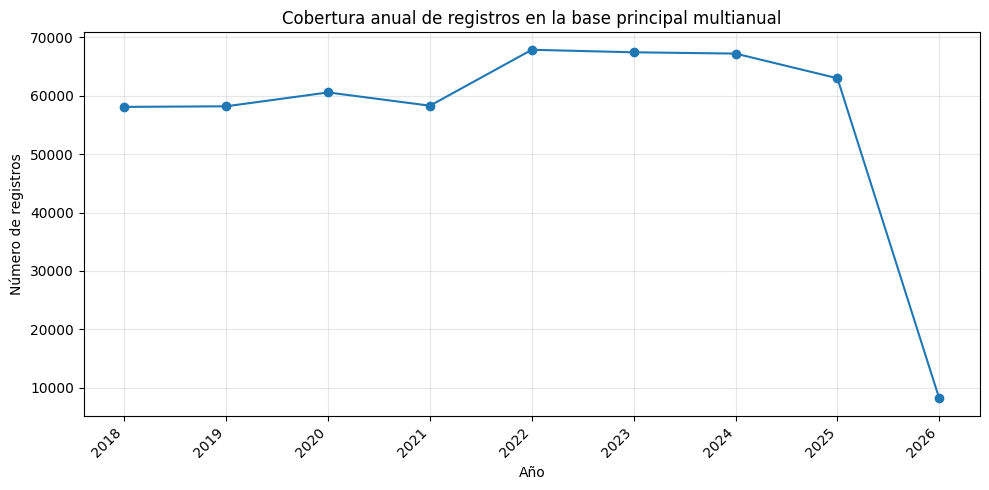

,mes_convocatoria,n_registros
0,2018-01,879
1,2018-02,3187
2,2018-03,4474
3,2018-04,4431
4,2018-05,5633
5,2018-06,4793
6,2018-07,4917
7,2018-08,5643
8,2018-09,5481
9,2018-10,6473


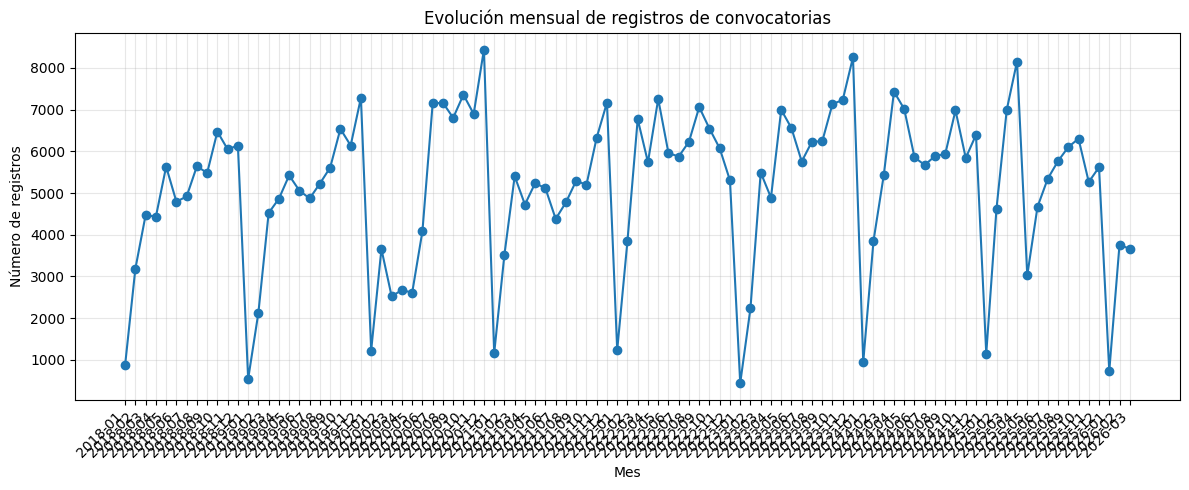

In [41]:
# ============================================================
# COBERTURA ANUAL DE LA BASE PRINCIPAL
# ============================================================

tabla_cobertura_anual = (
    base_trabajo_multianual
    .groupby("anio", as_index=False)
    .agg(
        n_registros=("llave_convocatoria", "count"),
        n_convocatorias_unicas=("llave_convocatoria", "nunique"),
        n_entidades=("entidad", "nunique"),
        n_departamentos=("departamento_item", "nunique")
    )
    .sort_values("anio")
)

guardar_csv(tabla_cobertura_anual, RUTA_RESULTADOS_RESUMENES / "tf_p3_cobertura_anual_base_principal.csv")
display(tabla_cobertura_anual)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tabla_cobertura_anual["anio"].astype(str), tabla_cobertura_anual["n_registros"], marker="o")
ax.set_title("Cobertura anual de registros en la base principal multianual")
ax.set_xlabel("Año")
ax.set_ylabel("Número de registros")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_cobertura_anual_base_principal.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# TRAYECTORIA MENSUAL DE LA BASE PRINCIPAL
# ============================================================

if "mes_convocatoria" in base_trabajo_multianual.columns:
    tabla_mensual = (
        base_trabajo_multianual
        .dropna(subset=["mes_convocatoria"])
        .groupby("mes_convocatoria", as_index=False)
        .agg(n_registros=("llave_convocatoria", "count"))
        .sort_values("mes_convocatoria")
    )

    guardar_csv(tabla_mensual, RUTA_RESULTADOS_TABLAS / "tf_p3_convocatorias_mensuales.csv")
    display(tabla_mensual.head(20))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tabla_mensual["mes_convocatoria"], tabla_mensual["n_registros"], marker="o")
    ax.set_title("Evolución mensual de registros de convocatorias")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Número de registros")
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_convocatorias_mensuales.png", dpi=300, bbox_inches="tight")
    plt.show()

,objeto_contractual,n,pct
0,Bien,252915,49.70
1,Servicio,171537,33.71
2,Obra,49797,9.78
3,Consultoría de Obra,34677,6.81


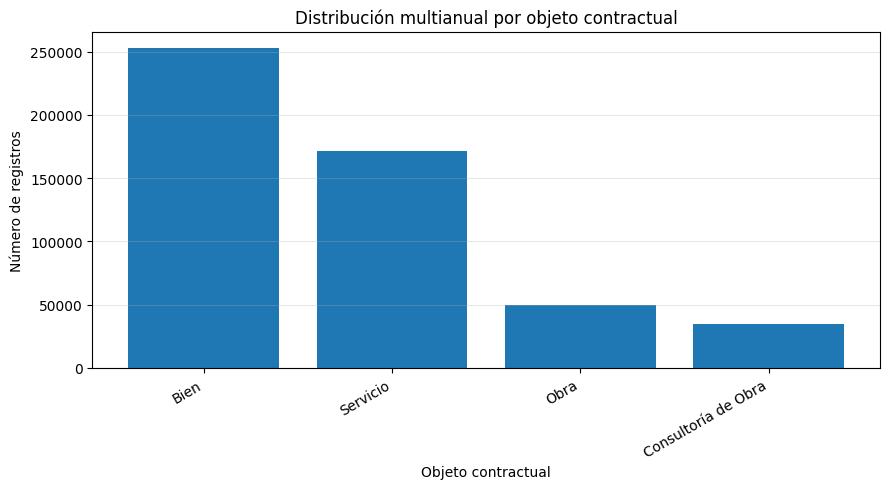

,entidad,n_registros
0,SEGURO SOCIAL DE SALUD,16522
1,EJERCITO PERUANO,11396
2,FUERZA AEREA DEL PERU,8180
3,PETROLEOS DEL PERU S.A.,7464
4,ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL,7357
5,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,6249
6,COMISION DE PROMOCION DEL PERU PARA LA EXPORTACION Y EL TURISMO - PROMPERU,5217
7,MARINA DE GUERRA DEL PERU,5141
8,GOBIERNO REGIONAL DE AYACUCHO SEDE CENTRAL,3863
9,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE NACIONAL (PROVIAS NACIONAL),3794


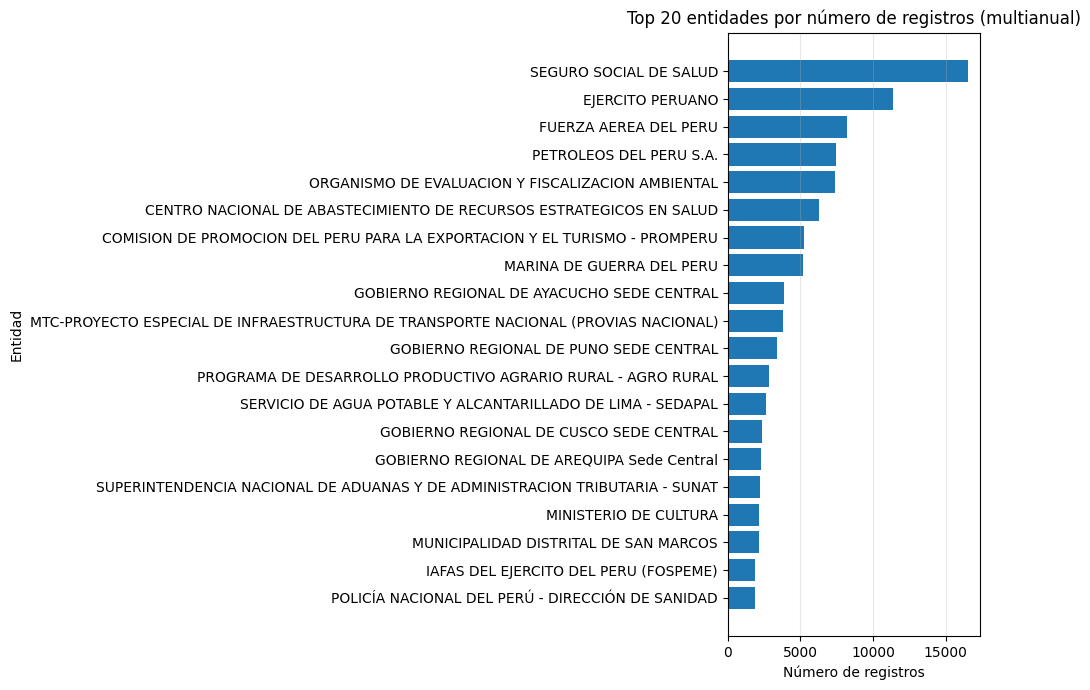

,departamento_item,n_registros
0,LIMA,149753
1,CUSCO,42265
2,ANCASH,25189
3,PIURA,23219
4,AREQUIPA,21020
5,PUNO,20767
6,LA LIBERTAD,19014
7,AYACUCHO,18514
8,JUNIN,18512
9,CAJAMARCA,17978


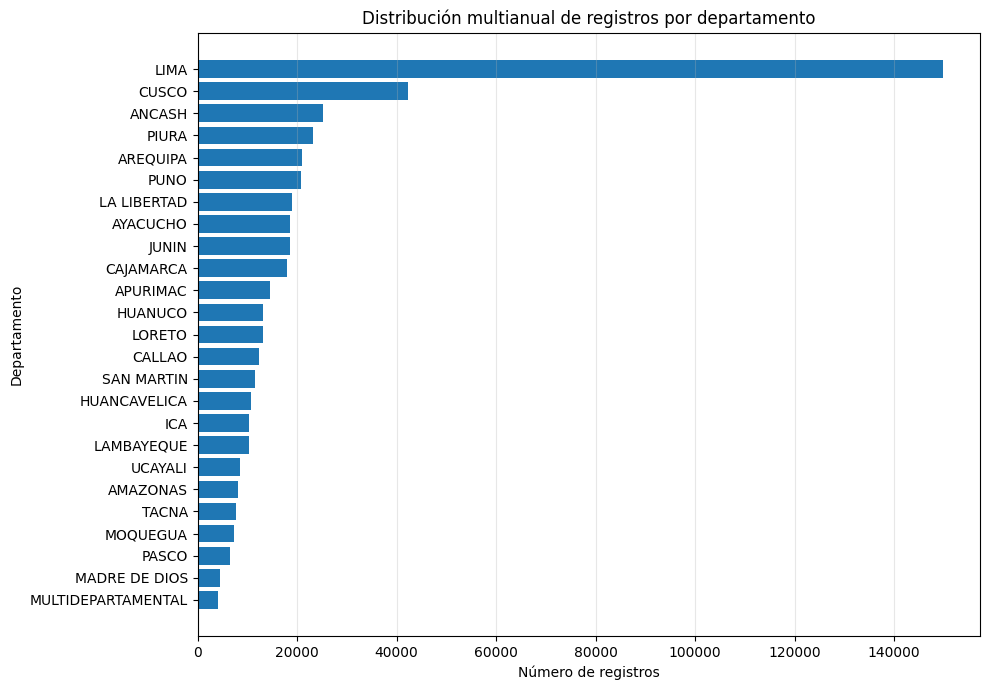

In [42]:
# ============================================================
# DISTRIBUCIÓN POR OBJETO CONTRACTUAL
# ============================================================

if "objeto_contractual" in base_trabajo_multianual.columns:
    tabla_objeto = (
        base_trabajo_multianual["objeto_contractual"]
        .fillna("sin_dato")
        .value_counts(dropna=False)
        .rename_axis("objeto_contractual")
        .reset_index(name="n")
    )
    tabla_objeto["pct"] = tabla_objeto["n"] / tabla_objeto["n"].sum() * 100

    guardar_csv(tabla_objeto, RUTA_RESULTADOS_TABLAS / "tf_p3_objeto_contractual.csv")
    display(tabla_objeto.round(2))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(tabla_objeto["objeto_contractual"], tabla_objeto["n"])
    ax.set_title("Distribución multianual por objeto contractual")
    ax.set_xlabel("Objeto contractual")
    ax.set_ylabel("Número de registros")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_objeto_contractual.png", dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# TOP ENTIDADES POR NÚMERO DE REGISTROS
# ============================================================

if "entidad" in base_trabajo_multianual.columns:
    tabla_entidades = (
        base_trabajo_multianual["entidad"]
        .fillna("sin_dato")
        .value_counts()
        .head(20)
        .rename_axis("entidad")
        .reset_index(name="n_registros")
    )

    guardar_csv(tabla_entidades, RUTA_RESULTADOS_TABLAS / "tf_p3_top_entidades.csv")
    display(tabla_entidades)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(tabla_entidades["entidad"][::-1], tabla_entidades["n_registros"][::-1])
    ax.set_title("Top 20 entidades por número de registros (multianual)")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel("Entidad")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_top_entidades.png", dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# DISTRIBUCIÓN TERRITORIAL POR DEPARTAMENTO
# ============================================================

if "departamento_item" in base_trabajo_multianual.columns:
    tabla_departamentos = (
        base_trabajo_multianual["departamento_item"]
        .fillna("sin_dato")
        .value_counts()
        .head(25)
        .rename_axis("departamento_item")
        .reset_index(name="n_registros")
    )

    guardar_csv(tabla_departamentos, RUTA_RESULTADOS_TABLAS / "tf_p3_departamentos.csv")
    display(tabla_departamentos)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(tabla_departamentos["departamento_item"][::-1], tabla_departamentos["n_registros"][::-1])
    ax.set_title("Distribución multianual de registros por departamento")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel("Departamento")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_departamentos.png", dpi=300, bbox_inches="tight")
    plt.show()

,n_validos,promedio,mediana,p25,p75,maximo
0,508926,2772742.69,191476.52,82423.25,564917.7,1.792432e+09


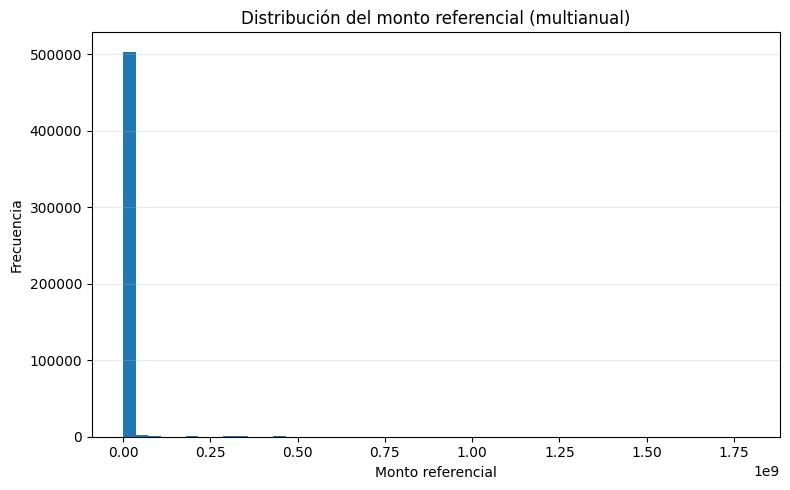

,anio,subconjunto,n_registros,pct_codigos_presentes_en_todos
0,2018,solo_subasta_inversa_electronica,5493,100.0
1,2018,solo_contratacion_directa,2929,100.0
2,2019,solo_subasta_inversa_electronica,6472,100.0
3,2019,solo_contratacion_directa,3892,100.0
4,2020,solo_subasta_inversa_electronica,5074,100.0
5,2020,solo_contratacion_directa,13268,100.0
6,2021,solo_subasta_inversa_electronica,6724,100.0
7,2021,solo_contratacion_directa,8769,100.0
8,2022,solo_subasta_inversa_electronica,8046,100.0
9,2022,solo_contratacion_directa,5465,100.0


,token,frecuencia
0,distrito,173205
1,provincia,138549
2,departamento,103845
3,mejoramiento,101498
4,proyecto,57261
5,ejecucion,55731
6,mantenimiento,50017
7,centro,33869
8,cusco,30729
9,agua,30403


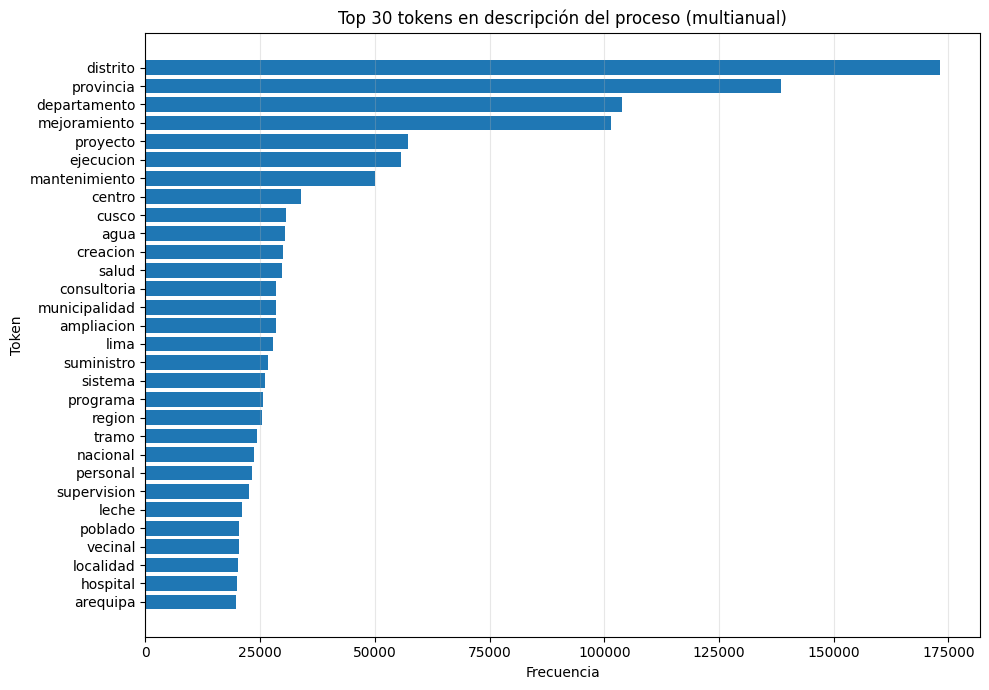

In [43]:
# ============================================================
# RESUMEN DE MONTOS
# ============================================================

if "monto_referencial_num" in base_trabajo_multianual.columns:
    tabla_montos = pd.DataFrame([{
        "n_validos": base_trabajo_multianual["monto_referencial_num"].notna().sum(),
        "promedio": base_trabajo_multianual["monto_referencial_num"].mean(),
        "mediana": base_trabajo_multianual["monto_referencial_num"].median(),
        "p25": base_trabajo_multianual["monto_referencial_num"].quantile(0.25),
        "p75": base_trabajo_multianual["monto_referencial_num"].quantile(0.75),
        "maximo": base_trabajo_multianual["monto_referencial_num"].max()
    }])

    guardar_csv(tabla_montos, RUTA_RESULTADOS_RESUMENES / "tf_p3_resumen_montos.csv")
    display(tabla_montos.round(2))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(base_trabajo_multianual["monto_referencial_num"].dropna(), bins=50)
    ax.set_title("Distribución del monto referencial (multianual)")
    ax.set_xlabel("Monto referencial")
    ax.set_ylabel("Frecuencia")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_hist_monto_referencial.png", dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# COBERTURA DE SUBCONJUNTOS DENTRO DE LA BASE GENERAL
# ============================================================

if col_codigo_conv is not None:
    registros_cobertura = []

    for anio in sorted(base_principal_multianual["anio"].astype(str).unique()):
        try:
            sub_general = base_principal_multianual[base_principal_multianual["anio"].astype(str) == anio]
            sub_sie = base_subasta_multianual[base_subasta_multianual["anio"].astype(str) == anio]
            sub_cd = base_contratacion_directa_multianual[base_contratacion_directa_multianual["anio"].astype(str) == anio]

            key_general = set(sub_general[col_codigo_conv].astype(str).dropna().str.strip())

            if not sub_sie.empty:
                key_sie = sub_sie[col_codigo_conv].astype(str).dropna().str.strip()
                registros_cobertura.append({
                    "anio": anio,
                    "subconjunto": "solo_subasta_inversa_electronica",
                    "n_registros": len(key_sie),
                    "pct_codigos_presentes_en_todos": (key_sie.isin(key_general)).mean() * 100 if len(key_sie) > 0 else np.nan
                })

            if not sub_cd.empty:
                key_cd = sub_cd[col_codigo_conv].astype(str).dropna().str.strip()
                registros_cobertura.append({
                    "anio": anio,
                    "subconjunto": "solo_contratacion_directa",
                    "n_registros": len(key_cd),
                    "pct_codigos_presentes_en_todos": (key_cd.isin(key_general)).mean() * 100 if len(key_cd) > 0 else np.nan
                })

        except Exception as e:
            print(f"No se pudo calcular cobertura para el año {anio}: {e}")

    tabla_cobertura_subconjuntos = pd.DataFrame(registros_cobertura)
    guardar_csv(tabla_cobertura_subconjuntos, RUTA_RESULTADOS_RESUMENES / "tf_p3_cobertura_subconjuntos_en_general.csv")
    display(tabla_cobertura_subconjuntos.round(2))

# ============================================================
# EXPLORACIÓN TEXTUAL MÍNIMA
# ============================================================

STOPWORDS_ES = {
    "de", "la", "el", "los", "las", "y", "o", "u", "en", "del", "al", "por",
    "para", "con", "sin", "un", "una", "unos", "unas", "se", "su", "sus",
    "que", "como", "a", "ante", "bajo", "contra", "desde", "durante", "entre",
    "hacia", "hasta", "mediante", "sobre", "tras", "lo", "le", "les", "es", "son",
    "ha", "han", "fue", "ser", "sea"
}

STOPWORDS_ADMIN = {
    "contratacion", "proceso", "servicio", "servicios", "adquisicion", "obra", "obras",
    "convocatoria", "item", "entidad", "contrato", "publica", "publico", "seleccion"
}

STOPWORDS_TOTALES = STOPWORDS_ES.union(STOPWORDS_ADMIN)

if "descripcion_proceso_limpia" in base_trabajo_multianual.columns:
    contador = Counter()

    for texto in base_trabajo_multianual["descripcion_proceso_limpia"].fillna(""):
        tokens = [t for t in texto.split() if len(t) >= 4 and t not in STOPWORDS_TOTALES]
        contador.update(tokens)

    top_30_tokens = pd.DataFrame(contador.most_common(30), columns=["token", "frecuencia"])
    guardar_csv(top_30_tokens, RUTA_RESULTADOS_TABLAS / "tf_p3_top_tokens_descripcion_proceso.csv")
    display(top_30_tokens)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_30_tokens["token"][::-1], top_30_tokens["frecuencia"][::-1])
    ax.set_title("Top 30 tokens en descripción del proceso (multianual)")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Token")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "tf_p3_top_tokens_descripcion_proceso.png", dpi=300, bbox_inches="tight")
    plt.show()

In [44]:
# ============================================================
# TABLA MAESTRA DE OUTPUTS
# ============================================================

tabla_outputs_p3 = pd.DataFrame([
    {"output": "Base comparativa multianual", "tipo": "tabla", "carpeta": "04_datos_procesados/tablas_unificadas"},
    {"output": "Base principal multianual", "tipo": "tabla", "carpeta": "04_datos_procesados/tablas_unificadas"},
    {"output": "Base limpia de trabajo", "tipo": "tabla", "carpeta": "04_datos_procesados/tablas_limpias"},
    {"output": "Cobertura anual", "tipo": "tabla+figura", "carpeta": "07_resultados/resumenes y figuras"},
    {"output": "Trayectoria mensual", "tipo": "tabla+figura", "carpeta": "07_resultados/tablas y figuras"},
    {"output": "Distribución por objeto contractual", "tipo": "tabla+figura", "carpeta": "07_resultados/tablas y figuras"},
    {"output": "Top entidades", "tipo": "tabla+figura", "carpeta": "07_resultados/tablas y figuras"},
    {"output": "Distribución territorial", "tipo": "tabla+figura", "carpeta": "07_resultados/tablas y figuras"},
    {"output": "Resumen de montos", "tipo": "tabla+figura", "carpeta": "07_resultados/resumenes y figuras"},
    {"output": "Cobertura de subconjuntos", "tipo": "tabla", "carpeta": "07_resultados/resumenes"},
    {"output": "Exploración textual mínima", "tipo": "tabla+figura", "carpeta": "07_resultados/tablas y figuras"},
    {"output": "Manifest final de ensamblaje", "tipo": "tabla", "carpeta": "00_admin"}
])

guardar_csv(tabla_outputs_p3, RUTA_ADMIN / "tf_p3_tabla_outputs_workflow.csv")
display(tabla_outputs_p3)

# ============================================================
# BITÁCORA METODOLÓGICA DE LA PARTE 3/3
# ============================================================

bitacora_p3 = pd.DataFrame([
    {
        "paso": 1,
        "descripcion": "Carga de artefactos auditados y lectura multianual de archivos Excel",
        "salida_principal": "Base comparativa multianual"
    },
    {
        "paso": 2,
        "descripcion": "Definición de base principal y subconjuntos comparativos",
        "salida_principal": "Base principal multianual"
    },
    {
        "paso": 3,
        "descripcion": "Identificación semiautomática de variables clave",
        "salida_principal": "Tabla de variables detectadas"
    },
    {
        "paso": 4,
        "descripcion": "Construcción de la tabla limpia de trabajo",
        "salida_principal": "Base_trabajo_multianual"
    },
    {
        "paso": 5,
        "descripcion": "Producción de tablas generales de cobertura y estructura",
        "salida_principal": "Tablas resumen multianuales"
    },
    {
        "paso": 6,
        "descripcion": "Producción de visualizaciones básicas y exportaciones",
        "salida_principal": "Figuras y tablas exportadas"
    },
    {
        "paso": 7,
        "descripcion": "Actualización del manifest final de ensamblaje y cierre del workflow",
        "salida_principal": "Manifest ensamblado"
    }
])

guardar_csv(bitacora_p3, RUTA_RESULTADOS_RESUMENES / "tf_p3_bitacora_metodologica.csv")
display(bitacora_p3)

print("Parte 3/3 completada correctamente.")

print("\nArchivos clave generados:")
print("-", RUTA_TABLAS_UNIFICADAS / "tf_p3_base_paquetes_multianual_raw.csv")
print("-", RUTA_TABLAS_UNIFICADAS / "tf_p3_base_principal_multianual_raw.csv")
print("-", RUTA_TABLAS_LIMPIAS / "tf_p3_base_trabajo_multianual.csv")
print("-", RUTA_RESULTADOS_RESUMENES / "tf_p3_resumen_general_base_principal_multianual.csv")
print("-", RUTA_RESULTADOS_RESUMENES / "tf_p3_cobertura_anual_base_principal.csv")
print("-", RUTA_RESULTADOS_TABLAS / "tf_p3_objeto_contractual.csv")
print("-", RUTA_RESULTADOS_TABLAS / "tf_p3_top_entidades.csv")
print("-", RUTA_RESULTADOS_TABLAS / "tf_p3_departamentos.csv")
print("-", RUTA_RESULTADOS_RESUMENES / "tf_p3_resumen_montos.csv")
print("-", RUTA_RESULTADOS_TABLAS / "tf_p3_top_tokens_descripcion_proceso.csv")
print("-", RUTA_ADMIN / "manifest_ensamblaje_actualizado.csv")

,output,tipo,carpeta
0,Base comparativa multianual,tabla,04_datos_procesados/tablas_unificadas
1,Base principal multianual,tabla,04_datos_procesados/tablas_unificadas
2,Base limpia de trabajo,tabla,04_datos_procesados/tablas_limpias
3,Cobertura anual,tabla+figura,07_resultados/resumenes y figuras
4,Trayectoria mensual,tabla+figura,07_resultados/tablas y figuras
5,Distribución por objeto contractual,tabla+figura,07_resultados/tablas y figuras
6,Top entidades,tabla+figura,07_resultados/tablas y figuras
7,Distribución territorial,tabla+figura,07_resultados/tablas y figuras
8,Resumen de montos,tabla+figura,07_resultados/resumenes y figuras
9,Cobertura de subconjuntos,tabla,07_resultados/resumenes


,paso,descripcion,salida_principal
0,1,Carga de artefactos auditados y lectura multianual de archivos Excel,Base comparativa multianual
1,2,Definición de base principal y subconjuntos comparativos,Base principal multianual
2,3,Identificación semiautomática de variables clave,Tabla de variables detectadas
3,4,Construcción de la tabla limpia de trabajo,Base_trabajo_multianual
4,5,Producción de tablas generales de cobertura y estructura,Tablas resumen multianuales
5,6,Producción de visualizaciones básicas y exportaciones,Figuras y tablas exportadas
6,7,Actualización del manifest final de ensamblaje y cierre del workflow,Manifest ensamblado


Parte 3/3 completada correctamente.

Archivos clave generados:
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/04_datos_procesados/tablas_unificadas/tf_p3_base_paquetes_multianual_raw.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/04_datos_procesados/tablas_unificadas/tf_p3_base_principal_multianual_raw.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/04_datos_procesados/tablas_limpias/tf_p3_base_trabajo_multianual.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/07_resultados/resumenes/tf_p3_resumen_general_base_principal_multianual.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/07_resultados/resumenes/tf_p3_cobertura_anual_base_principal.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/07_resultados/tablas/tf_p3_objeto_contractual.csv
- /content/drive/MyDrive/IA Generativa para CCSS/Trabajo Final/07_resultados/tablas/tf_p3_top_entidades.csv
- /content/drive/MyDrive/IA Generati